# 2 · Hasard et statistiques de base — solutions (notebook exécuté)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cemah2/workbookIA/blob/main/chapitres/ch02_stats/05_solutions.ipynb)

Les réponses des exercices, exécutées. Les démarches détaillées (le *pourquoi*, les erreurs fréquentes, les variantes) sont dans `05_solutions.md`. Les cellules marquées `answer` enregistrent les réponses vérifiées par `wb.check` (`tools/build_answers.py`).

| Partie | ID | Titre | Type | ★ | ⏱️ |
|---|---|---|---|---|---|
| 0 | 2.1 à 2.7 | vérifier tes exercices papier ✏️ | ✏️ | ★ à ★★ | |
| A | 2.13 | Tendances centrales : `mean`, `median`, `mode` | 🔨 | ★★ | 30 |
|  | 2.14 | Graine fixée ou graine libre ? | 🔮 | ★ | 10 |
|  | 2.15 | Dispersion : `variance`, `std`, `percentile`, `zscore` | 🔨 | ★★★ | 40 |
|  | 2.16 | Un histogramme fait maison | 🔨 | ★★ | 20 |
|  | 2.17 | Galerie des lois usuelles | 🎨 | ★★ | 20 |
|  | 2.18 | 68-95-99,7 : la théorie face aux tirages et aux manchots | 🔬 | ★★ | 20 |
| B | 2.19 | La roue de la fortune : tirer dans une distribution discrète | 🔨 | ★★ | 25 |
|  | 2.20 | Le pelage des animaux : une variable qui dépend d'une autre | 🔮 | ★★ | 15 |
|  | 2.21 | Tirer avec ou sans remise | 🔨 | ★★ | 20 |
| C | 2.22 | Bootstrap : distribution et intervalle de confiance | 🔨 | ★★ | 30 |
|  | 2.23 | Bootstraps de 20 (livre) ou de n (aujourd'hui) ? | 🔬 | ★★ | 30 |
|  | 2.24 | Comparer avec `scipy.stats.bootstrap` | 📦 | ★★ | 15 |
| D | 2.25 | Distances entre chiffres dans l'espace à 784 dimensions | 📦 | ★★ | 25 |
|  | 2.26 | Covariance et corrélation | 🔨 | ★★ | 25 |
|  | 2.27 | Deviner la corrélation d'un nuage de points | 📈 | ★★ | 20 |
|  | 2.28 | Matrices de covariance et de corrélation des manchots | 🔨 | ★★ | 25 |
|  | 2.29 | Le piège de ddof : NumPy, pandas et toi | 🐛 | ★★ | 20 |
|  | 2.30 | Le quartet d'Anscombe | 🎨 | ★★ | 25 |
|  | 2.31 | Docstring et test pytest pour `zscore` | 🛠️ | ★★ | 30 |
|  | 2.32 | Mêmes statistiques, autre dessin : fabrique ton quartet | 🏆 | ★★★ | 60 |

In [1]:
# ⚙️ SETUP: run this cell first (on Colab or on your computer)
FAST_MODE = True  # True = quick version (CPU, a few minutes); False = full version
SEED = 42

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/cemah2/workbookIA.git"
DRIVE_DIR = Path("/content/drive/MyDrive/workbookIA")

try:
    import google.colab  # noqa: F401  (this module only exists on Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(DRIVE_DIR)])
    if not (DRIVE_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(DRIVE_DIR)], check=True)
    else:
        # Get the new chapters. Your own work only lives in mon_travail/, which Claude never
        # touches, so "rebase + autostash" keeps it safe (even with local commits).
        identity = subprocess.run(["git", "-C", str(DRIVE_DIR), "config", "user.email"],
                                  capture_output=True).returncode == 0
        who = [] if identity else ["-c", "user.name=Workbook", "-c", "user.email=workbook@localhost"]
        pull = subprocess.run(["git", *who, "-C", str(DRIVE_DIR), "pull", "--rebase", "--autostash"],
                              capture_output=True, text=True)
        conflicts = subprocess.run(["git", "-C", str(DRIVE_DIR), "diff", "--name-only", "--diff-filter=U"],
                                   capture_output=True, text=True).stdout.split()
        if conflicts:  # a file changed outside mon_travail/ AND by Claude: git leaves conflict markers in it
            print("⚠️ Tes modifications de " + ", ".join(conflicts) + " (hors de mon_travail/) entrent en conflit "
                  "avec la nouvelle version ; elles sont gardées dans `git stash`. Pour reprendre la version du "
                  "dépôt : git restore --source=HEAD --staged --worktree <fichier> (00_setup/COLAB.md, « Problèmes "
                  "fréquents »).")
        elif pull.returncode != 0:
            print("⚠️ git pull a échoué (voir 00_setup/COLAB.md, « Problèmes fréquents ») :\n" + pull.stderr)
    ROOT = DRIVE_DIR
else:
    ROOT = Path(os.environ.get("WB_ROOT", Path.cwd())).resolve()
    while not (ROOT / "src" / "wb").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    if not (ROOT / "src" / "wb").exists():
        raise FileNotFoundError("Dépôt introuvable : ouvre ce notebook depuis le dossier du workbook.")

os.environ["WB_ROOT"] = str(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import wb  # noqa: E402

cfg = wb.setup(seed=SEED, fast=FAST_MODE)
FAST_MODE = cfg.fast
mylearn = wb.load_mylearn("ref")  # reference implementation

🧪 Deep Learning Workbook : environnement
   Plateforme : Local (Linux x86_64, 2 CPU)
   Python 3.13.13 | numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | scikit-learn 1.6.1 | scipy 1.16.3 | torch 2.11.0+cpu | torchvision 0.26.0+cpu
   Device : cpu | Graine : 42 | FAST_MODE : True


## Objectifs et rappel express

- Résumer des données par un centre (moyenne, médiane, mode) et une dispersion (variance, écart-type, percentiles), et savoir lequel choisir.
- Tirer au hasard de façon reproductible, dans une loi discrète, avec ou sans remise.
- Mesurer l'incertitude d'une statistique par le bootstrap.
- Calculer et interpréter covariance et corrélation, et toujours regarder les données.

**Rappel express.** $\bar{x} = \frac{1}{n}\sum_i x_i$ ; $\mathrm{Var}(x) = \frac{1}{n - \mathrm{ddof}}\sum_i (x_i - \bar{x})^2$ et $\sigma = \sqrt{\mathrm{Var}(x)}$ ; $z_i = \frac{x_i - \bar{x}}{\sigma}$ ; loi normale : 68 %, 95 %, 99,7 % des tirages à moins de 1, 2, 3 écarts-types de la moyenne ; $\mathbb{E}[X] = \sum_k x_k\,p_k$ ; $\mathrm{Cov}(x, y) = \frac{1}{n - \mathrm{ddof}}\sum_i (x_i - \bar{x})(y_i - \bar{y})$ et $r = \frac{\mathrm{Cov}(x, y)}{\sigma_x\,\sigma_y}$. En NumPy : `rng = np.random.default_rng(seed)`, `x.var(ddof=...)`, `np.percentile`, `np.cov(x, y)`, `np.corrcoef(x, y)`.

## Partie 0 · Vérifier tes exercices papier (✏️ de 2.1 à 2.7)

Fais d'abord les exercices ✏️ de `02_exercices.md` **sur papier**, dans ta copie de `06_mes_reponses.md`. Reporte ensuite chaque réponse ici : **la valeur** que tu as trouvée (par exemple `42`, `0.125`, `[7, -2]` ou `"texte"`), pas l'expression Python, sinon tu ne vérifies rien. Arrondis comme l'énoncé le demande. Les réponses pas encore remplies affichent ⏳. L'exercice ∂ 2.8 se corrige avec `05_solutions.md`.

In [2]:
# The paper exercises only use the numbers of their statements (02_exercices.md)
import math

import numpy as np

SALARIES = np.array([2300, 12000, 2100, 1900, 2800, 2400, 3500, 2100, 2600])     # 2.1
CARS = np.array([176, 144, 224, 96, 160])            # 2.2: sedans, pick-ups, minivans, SUVs, estates
CAR_TYPES = ["berline", "pick-up", "monospace", "SUV", "break"]
LOADING = np.array([4, 7, 6, 3, 10])                  # 2.4
STUDY = np.array([1, 2, 3, 4, 5])                     # 2.7: hours of revision
GRADES = np.array([2, 3, 5, 4, 6])                    # 2.7: grades

**Ex 2.1 — Moyenne, médiane et mode d'une liste de salaires**

In [3]:
wb.record("2.1a", round(SALARIES.mean()), mistakes={"il y a 9 salariés : divise la somme par 9": round(SALARIES.sum() / 10), "c'est la médiane : on demande la moyenne": 2400})
wb.record("2.1b", int(np.median(SALARIES)), mistakes={"trie d'abord les salaires : la médiane est la valeur du milieu de la liste TRIÉE": 2800, "c'est la moyenne : on demande la médiane": round(SALARIES.mean())})
wb.record("2.1c", 2100, mistakes={"le mode est la valeur la plus FRÉQUENTE, pas celle du milieu": 2400})
wb.record("2.1d", int((SALARIES < SALARIES.mean()).sum()), mistakes={"on demande ceux qui gagnent MOINS que la moyenne": 1, "compare chaque salaire à la moyenne, pas à la médiane": 4})
wb.record("2.1e", round(np.where(SALARIES == 12000, 30000, SALARIES).mean()), mistakes={"la moyenne dépend de TOUS les salaires : recalcule-la avec le nouveau": round(SALARIES.mean())})
wb.record("2.1f", int(np.median(np.where(SALARIES == 12000, 30000, SALARIES))), mistakes={"c'est la nouvelle moyenne : on demande la médiane": round(np.where(SALARIES == 12000, 30000, SALARIES).mean()), "trie d'abord les salaires : la médiane est la valeur du milieu de la liste TRIÉE": 2800})

WB_ANSWER {"hash": "f4633d605a6263501548fa92e6649630adbcd5b2c449307069331b077099d4a4", "id": "2.1a", "kind": "int", "magnitude": 3, "mistakes": {"6e431e5e36849a7008b49df24efa776e4ea0d3dfaeaeb99301eb23414d4625a8": "il y a 9 salariés : divise la somme par 9", "faa9461aa9a729784742680a3c30f7e94d11e5604bce7385475bbf5420f33443": "c'est la médiane : on demande la moyenne"}, "sign": 1}
📝 Ex 2.1a : réponse enregistrée (int).
WB_ANSWER {"hash": "24c261befcc9f2721145dd61510bc6cdc1af7eedc17662434aef0fa655f24fb5", "id": "2.1b", "kind": "int", "magnitude": 3, "mistakes": {"2f4434fa662dacf80e2a0def49d804d824e669e6f7345f9565dfda97c1cb8f95": "c'est la moyenne : on demande la médiane", "4c372534b370916219cfbc6baea9f92f2c12c17f8cb8faa20d350128e27f76dc": "trie d'abord les salaires : la médiane est la valeur du milieu de la liste TRIÉE"}, "sign": 1}
📝 Ex 2.1b : réponse enregistrée (int).
WB_ANSWER {"hash": "67f4d34e0a12a4319894de36a7ad983babe2bdccf305fa25c1e94f4eff26ab99", "id": "2.1c", "kind": "int", "ma

**Ex 2.2 — De la casse de voitures à la distribution de probabilité**

In [4]:
wb.record("2.2a", CARS[2] / CARS.sum(), decimals=2, mistakes={"divise le nombre de monospaces par le nombre TOTAL de voitures": 224})
wb.record("2.2b", (CARS / CARS.sum()).tolist(), decimals=2, mistakes={"ce sont les comptages : divise chacun par le total": CARS.tolist(), "exprime les probabilités entre 0 et 1, pas en pourcentage": (100 * CARS / CARS.sum()).tolist()})
wb.record("2.2c", 360 * CARS[2] / CARS.sum(), decimals=1, mistakes={"c'est un pourcentage : un tour complet de roue fait 360°": 28, "multiplie la probabilité par 360° (un tour complet)": 0.28})
wb.record("2.2d", 1 - CARS[3] / CARS.sum(), decimals=2, mistakes={"c'est la probabilité de tirer un SUV : on demande l'événement contraire": 0.12})
wb.record("2.2e", 50 * CARS[1] / CARS.sum(), decimals=1, mistakes={"c'est la probabilité d'un seul tirage : multiplie-la par le nombre de tirages": 0.18})
wb.record("2.2f", np.cumsum(CARS / CARS.sum()).tolist(), decimals=2, mistakes={"ce sont les probabilités elles-mêmes : additionne-les au fur et à mesure": (CARS / CARS.sum()).tolist()})
wb.record("2.2g", CAR_TYPES[int(np.searchsorted(np.cumsum(CARS / CARS.sum()), 0.71, side='right'))], mistakes={"le type choisi est le premier dont la somme cumulée est strictement plus grande que u": "monospace", "compare u aux sommes cumulées de la question f, dans l'ordre de l'énoncé": "break"})

WB_ANSWER {"decimals": 2, "hash": "dd0bad7c634b7a19ca07d30b0a56a1a2e235e168e19a7a2fec68794978db238c", "hash_coarse": "f6d268734dee1540cb7ff82deed60079862555846c4b2763c980a1d71a65e73c", "id": "2.2a", "kind": "float", "magnitude": -1, "mistakes": {"91ab46b571504e452510fc1aa4889b203b4d74ac03d3cd88f9c4119f91b1086e": "divise le nombre de monospaces par le nombre TOTAL de voitures"}, "sign": 1}
📝 Ex 2.2a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 2, "element_coarse": [["abca11c3b703f41cd4816dce88010c2ee503a8dc58cf4d03da41881af6530407"], ["9f1dae65b7a82c10e62aaee6f1d53852bc946a7d951bacc9de415e185be65588"], ["b7d4404f5f0435f718281f2ec28e070dba237e495e461614221cb84bd3318616"], ["10dd0a3eb7cabc6a46da034dbcd6fbd4680a06f15ff382cd4d8c53703f70de5b"], ["5607509df81289dbaa93fa0e3cb168c515cd15e08a8bb1dc9703ba155c2c2010"]], "element_hashes": ["dfa90d1ca5518f95c1a134862cb24d5ca588040e0e598ab832cb33243f34bee8", "512cc2614bba0760bc0f632562151ac4433fc9acb9b0474f1addaa76ab3fa9ce", "

**Ex 2.3 — La règle 68-95-99,7 sur les nageoires des manchots**

In [5]:
wb.record("2.3a", [190 - 6.5, 190 + 6.5], decimals=1, mistakes={"c'est l'intervalle à 2 écarts-types (95 %)": [177, 203], "c'est l'intervalle à 3 écarts-types (99,7 %)": [170.5, 209.5]})
wb.record("2.3b", [190 - 2 * 6.5, 190 + 2 * 6.5], decimals=1, mistakes={"c'est l'intervalle à 1 écart-type (68 %)": [183.5, 196.5], "c'est l'intervalle à 3 écarts-types (99,7 %)": [170.5, 209.5]})
wb.record("2.3c", (1 - 0.95) / 2, decimals=3, mistakes={"les 5 % hors de l'intervalle se partagent entre les DEUX côtés (symétrie)": 0.05, "c'est la part EN DESSOUS de 203 mm": 0.975, "c'est la part DANS l'intervalle": 0.95, "l'énoncé demande d'utiliser la règle 68-95-99,7, pas une table de la loi normale": 0.023})
wb.record("2.3d", round(151 * 0.025), mistakes={"seuls ceux AU-DESSUS de 203 mm comptent, pas ceux des deux côtés": round(151 * 0.05), "arrondis au plus proche, ne tronque pas (et utilise la règle 68-95-99,7, pas une table)": 3})
wb.record("2.3e", (210 - 190) / 6.5, decimals=2, mistakes={"arrondis au plus proche, ne tronque pas": 3.07, "divise l'écart à la moyenne par l'écart-type": 20})

WB_ANSWER {"decimals": 1, "element_hashes": ["c9fa6ef4ff33b0a7b8d288dcd7c40f536b7c2221fadd7523ded35512a7cd0fe4", "34ba2d59d5acfc9f283020333d3055a6b9b76feb8784b028d20475017fa216b1"], "hash": "9def0ee66695c7aff34759c1c6fde30497d7140d7c8b6d2490ef3d89a33d7153", "id": "2.3a", "kind": "array", "mistakes": {"e290f64f6ec18137d6235dd822441f84bad0e093c70bbcb654f78123c62ff9fb": "c'est l'intervalle à 2 écarts-types (95 %)", "f3e769ea92307f06005b70ef9933ffb5631e0701ee86eaed15498dffdd72071a": "c'est l'intervalle à 3 écarts-types (99,7 %)"}, "shape": [2]}
📝 Ex 2.3a : réponse enregistrée (array, 1 décimale(s)).
WB_ANSWER {"decimals": 1, "element_hashes": ["c22604505d2e02266bc3e0cfa1037eb257cfa19fa1931d7e97bd52902170af21", "d9e8662e88f8561cce31dc0d00591e59ed6dd286b6a00cc5f5107dbebc934511"], "hash": "d8a473a7e6989a5b74f39f4bb58ea87674c7b8326bc7488a5764f6b050300930", "id": "2.3b", "kind": "array", "mistakes": {"1cf43336e925c035c0325f0fb1041bf58717825e3b6d88c41432b5cde760b8f6": "c'est l'intervalle à 1 éca

**Ex 2.4 — Variance : diviser par N ou par N − 1 ?**

In [6]:
wb.record("2.4a", int(LOADING.mean()))
wb.record("2.4b", int(((LOADING - LOADING.mean()) ** 2).sum()), mistakes={"élève chaque écart au carré AVANT d'additionner (la somme des écarts vaut toujours 0)": 0, "ce sont les écarts en valeur absolue : il faut leurs CARRÉS": int(np.abs(LOADING - LOADING.mean()).sum())})
wb.record("2.4c", LOADING.var(), decimals=2, mistakes={"ddof = 0 : divise par n, pas par n − 1": LOADING.var(ddof=1), "c'est l'écart-type : on demande la variance": LOADING.std()})
wb.record("2.4d", LOADING.var(ddof=1), decimals=2, mistakes={"ddof = 1 : divise par n − 1, pas par n": LOADING.var()})
wb.record("2.4e", LOADING.std(), decimals=3, mistakes={"c'est la variance : prends sa racine carrée": LOADING.var(), "c'est l'écart-type avec ddof = 1": LOADING.std(ddof=1)})
wb.record("2.4f", LOADING.std(ddof=1), decimals=3, mistakes={"c'est la variance : prends sa racine carrée": LOADING.var(ddof=1), "c'est l'écart-type avec ddof = 0": LOADING.std()})
wb.record("2.4g", (LOADING ** 2).mean(), decimals=2, mistakes={"c'est le carré de la moyenne : on demande la moyenne des carrés": 36, "c'est la somme des carrés : divise-la par le nombre de valeurs": int((LOADING ** 2).sum())})
wb.record("2.4h", (LOADING + 100).var(), decimals=2, mistakes={"ajouter 100 décale les valeurs ET leur moyenne : les écarts ne changent pas": 106})
wb.record("2.4i", (LOADING * 1000).std(), decimals=1, mistakes={"c'est la variance : elle est multipliée par 1 000², l'écart-type par 1 000": (LOADING * 1000).var(), "multiplier les valeurs par 1 000 multiplie aussi les écarts": LOADING.std(), "tu es reparti de l'écart-type arrondi : pars de sa valeur exacte (la racine de la variance)": 2449.0})

WB_ANSWER {"hash": "95cf0084678a7d0b50f9fff8ad01c9daa38d1805f3eae14e735cc6749020307b", "id": "2.4a", "kind": "int", "magnitude": 0, "sign": 1}
📝 Ex 2.4a : réponse enregistrée (int).
WB_ANSWER {"hash": "a239ef4ea2a3219ac1f2d58be2abdf91db98d1b8bf4208df4e275f118edf15ad", "id": "2.4b", "kind": "int", "magnitude": 1, "mistakes": {"06a02b2f93e5e8de601280533f56c32d8f75216c6824a4803e4fcc0eb5684025": "ce sont les écarts en valeur absolue : il faut leurs CARRÉS", "191b6e7928e4a125efa46c8ff795037f45be7c1d8e42f1ce2b6b4e4554c5bca0": "élève chaque écart au carré AVANT d'additionner (la somme des écarts vaut toujours 0)"}, "sign": 1}
📝 Ex 2.4b : réponse enregistrée (int).
WB_ANSWER {"decimals": 2, "hash": "16f81a5b823dca6801cc5dc6d2fdfa7cd560cb9e79f14116193262a93e5b088f", "hash_coarse": "3447ab8320f44ce05f382424842765b2379522ee797607ef2a1b652318b831d6", "id": "2.4c", "kind": "float", "magnitude": 0, "mistakes": {"2570bc369cc433ad2881f791f285c93383486349c534cee2da4dfb2ec7b33bdd": "ddof = 0 : divise pa

**Ex 2.5 — Espérances : Bernoulli, multinoulli et jeu de hasard**

In [7]:
wb.record("2.5a", 0.3, decimals=2)
wb.record("2.5b", 0.3 * (1 - 0.3), decimals=2, mistakes={"c'est l'espérance : la variance d'une loi de Bernoulli vaut p(1 − p)": 0.3, "c'est p² : la variance vaut p(1 − p)": 0.09})
wb.record("2.5c", 200 * 0.3, decimals=1, mistakes={"c'est l'espérance d'un seul lancer : multiplie par le nombre de lancers": 0.3})
wb.record("2.5d", sum(range(1, 21)) / 20, decimals=1, mistakes={"la moyenne de 1, 2, …, 20 vaut (1 + 20) / 2": 10, "divise la somme des faces par le nombre de faces": sum(range(1, 21))})
wb.record("2.5e", 1 * 0.1 + 2 * 0.2 + 3 * 0.3 + 4 * 0.4, decimals=1, mistakes={"pondère chaque numéro par SA probabilité (ce n'est pas la moyenne de 1, 2, 3, 4)": 2.5})
wb.record("2.5f", [0, 0, 1, 0], mistakes={"les classes sont numérotées de 1 à 4 : la classe 3 est la troisième composante": [0, 0, 0, 1]})
wb.record("2.5g", [0.1, 0.2, 0.3, 0.4], decimals=2, mistakes={"les classes ne sortent pas toutes aussi souvent : pense à la fréquence de chacune": [0.25, 0.25, 0.25, 0.25]})
wb.record("2.5h", 20 / 20 + 5 * 3 / 20 - 2, decimals=2, mistakes={"déduis la mise de 2 € du gain moyen": 20 / 20 + 5 * 3 / 20, "la mise n'est jamais rendue : tu paies 2 € à chaque partie, même quand tu gagnes": 0.15})
wb.record("2.5i", -400 * (20 / 20 + 5 * 3 / 20 - 2), decimals=1, mistakes={"le gain de l'organisateur est l'opposé de celui du joueur": 400 * (20 / 20 + 5 * 3 / 20 - 2), "c'est le gain moyen d'une seule partie : multiplie par le nombre de parties": 0.25})

WB_ANSWER {"decimals": 2, "hash": "aa246ea00c1e407d787049b9b368e2c49f547344d881423e6891affcb3556fc0", "hash_coarse": "c29f6ff3ff85ef5e61a42abaeb1255b8ced7c3ef53bc90843ede71077fb177fd", "id": "2.5a", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 2.5a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "e0d1bcf682560303d47e4c99193c80a718f744d295e7188d51aa5d475b4fdf8b", "hash_coarse": "3150c2be1eb6febb0917d3d64d2780df20cd4a5353988be420dc12204f3277ea", "id": "2.5b", "kind": "float", "magnitude": -1, "mistakes": {"34371fede7651ed2c7d5dd03628d2388a686a21ce61bdfb6ff9ba6a67f8e6c5a": "c'est l'espérance : la variance d'une loi de Bernoulli vaut p(1 − p)", "c554b3ee82fe6e36d40c438b78ee674c07084024a53dc42b2963c86820000ab5": "c'est p² : la variance vaut p(1 − p)"}, "sign": 1}
📝 Ex 2.5b : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "88823c0399dfcfb890347476ef9de724fc9d1e62110421cff90c23ecb094b833", "hash_coarse": "99ffa01785f9d4f640cd

**Ex 2.6 — Compter les tirages avec et sans remise**

In [8]:
wb.record("2.6a", math.comb(5, 2), mistakes={"sans tenir compte de l'ordre, AB et BA forment le même jeu": 20})
wb.record("2.6b", math.comb(5 + 2 - 1, 2), mistakes={"sans tenir compte de l'ordre, AB et BA ne comptent qu'une fois": 25, "avec remise, AA, BB… sont possibles aussi": 10})
wb.record("2.6c", 5 ** 2, mistakes={"ici l'ordre compte : AB et BA sont deux suites différentes": 15, "avec remise, un exemple peut sortir deux fois (AA)": 20})
wb.record("2.6d", math.comb(7, 3), mistakes={"sans tenir compte de l'ordre : chaque groupe de 3 correspond à 3! = 6 suites": 210, "sans remise, un exemple ne peut pas sortir deux fois": 343})
wb.record("2.6e", 5 ** 5, mistakes={"il y a 5 tirages, pas 2": 25, "avec remise : chacun des 5 tirages a 5 issues possibles": 120})
wb.record("2.6f", (1 - 1 / 5) ** 5, decimals=4, mistakes={"on veut l'absence à CHACUN des 5 tirages (indépendants)": 0.8, "c'est la probabilité d'apparaître AU MOINS une fois": 1 - 0.8 ** 5, "c'est la probabilité d'être tiré à un tirage donné": 0.2, "c'est la limite quand n devient très grand ; ici n = 5 : calcule la valeur exacte": math.exp(-1)})
wb.record("2.6g", (1 - 1 / 1000) ** 1000, decimals=4, mistakes={"c'est la limite quand n devient infini : calcule la valeur exacte pour n = 1 000": math.exp(-1)})
wb.record("2.6h", 1 - (1 - 1 / 1000) ** 1000, decimals=4, mistakes={"c'est la part des exemples ABSENTS du rééchantillon": (1 - 1 / 1000) ** 1000, "c'est la limite 1 − e^(−1) : calcule la valeur exacte pour n = 1 000": 1 - math.exp(-1)})

WB_ANSWER {"hash": "195ba363a054b7c8f70c349f6cd9698c1728bc06f6e69ac605ae87639dc63ae5", "id": "2.6a", "kind": "int", "magnitude": 1, "mistakes": {"e776a306e53add25800947945e89c0630ccb6075293704cb285d382478814e32": "sans tenir compte de l'ordre, AB et BA forment le même jeu"}, "sign": 1}
📝 Ex 2.6a : réponse enregistrée (int).
WB_ANSWER {"hash": "9c0b4072d128a08c7af03e48a57f5230eaa6d4cce9122db2febbfad632cfe577", "id": "2.6b", "kind": "int", "magnitude": 1, "mistakes": {"25869adaa8f4495d86f11d89434630c984186c1e66edab18676b4a428fcdda28": "avec remise, AA, BB… sont possibles aussi", "66721c913d29557d371385c167f3b133d92376308e6042b2ccd8b7db31d67d33": "sans tenir compte de l'ordre, AB et BA ne comptent qu'une fois"}, "sign": 1}
📝 Ex 2.6b : réponse enregistrée (int).
WB_ANSWER {"hash": "e946211b3b23dd31c157c34db96c391658ae51250d859d6af55b665fe03d1266", "id": "2.6c", "kind": "int", "magnitude": 1, "mistakes": {"0c12c2da48bdca774e9accbc6a7b848e5ea463536010050985b11e45946b6f8b": "ici l'ordre compt

**Ex 2.7 — Covariance et corrélation de cinq points à la main**

In [9]:
wb.record("2.7a", [STUDY.mean(), GRADES.mean()], decimals=1)
wb.record("2.7b", float(((STUDY - STUDY.mean()) * (GRADES - GRADES.mean())).sum()), decimals=1, mistakes={"additionne les PRODUITS des écarts de x et de y, pas les écarts eux-mêmes": 0, "c'est déjà la covariance (divisée par n) : on demande la somme des produits": 1.8})
wb.record("2.7c", np.cov(STUDY, GRADES, ddof=0)[0, 1], decimals=2, mistakes={"divise la somme des produits par le nombre de points": 9, "ddof = 0 : divise par n, pas par n − 1": np.cov(STUDY, GRADES, ddof=1)[0, 1]})
wb.record("2.7d", np.cov(STUDY, GRADES, ddof=1)[0, 1], decimals=2, mistakes={"ddof = 1 : divise par n − 1, pas par n": np.cov(STUDY, GRADES, ddof=0)[0, 1]})
wb.record("2.7e", [STUDY.std(), GRADES.std()], decimals=3, mistakes={"ce sont les variances : prends leur racine carrée": [STUDY.var(), GRADES.var()]})
wb.record("2.7f", np.corrcoef(STUDY, GRADES)[0, 1], decimals=3, mistakes={"tu as mélangé ddof = 1 (covariance) et ddof = 0 (écarts-types) : une corrélation ne dépasse jamais 1": np.cov(STUDY, GRADES, ddof=1)[0, 1] / (STUDY.std() * GRADES.std()), "divise la covariance par le PRODUIT des deux écarts-types": 0.45, "tu as mélangé ddof = 0 (covariance) et ddof = 1 (écarts-types) : garde le même ddof partout": np.cov(STUDY, GRADES, ddof=0)[0, 1] / (STUDY.std(ddof=1) * GRADES.std(ddof=1))})
wb.record("2.7g", np.cov(STUDY * 60, GRADES, ddof=0)[0, 1], decimals=1, mistakes={"la covariance dépend de l'unité de x : elle change": 1.8, "seul x est multiplié par 60, pas y": 1.8 * 3600})
wb.record("2.7h", np.corrcoef(STUDY * 60, GRADES)[0, 1], decimals=3, mistakes={"c'est la covariance : la corrélation divise par les écarts-types": 108})

WB_ANSWER {"decimals": 1, "element_hashes": ["2b01e4b4abc920c6d6e2fcd4cbb641ad3f7f78a9afc1aeb128c1052084ad12ac", "0ed3708c092f13e8dd57990b10642d81b2bc3cfb5c069f43d408ca0103b45767"], "hash": "686e878d2ea4fe885a54b096ceb0c939acb7c160eb7c92e1b6f7eed41d0398a3", "id": "2.7a", "kind": "array", "shape": [2]}
📝 Ex 2.7a : réponse enregistrée (array, 1 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "851e0026d280446152f543bb6ce40aba612d368beb9325fad9290df52a78dff8", "hash_coarse": "973fd1ea6263fef61bdcb685ff114f741717ab1ee2b677107f54b927a26b0848", "id": "2.7b", "kind": "float", "magnitude": 0, "mistakes": {"9d605dbed4ce238ee3dfdd373f6c8917a33c4efac78998137e0fe3dadd7c857a": "additionne les PRODUITS des écarts de x et de y, pas les écarts eux-mêmes", "a9495e7f4df27f87832cf39338e046667a181d86ecace43d4cf870250ba1188a": "c'est déjà la covariance (divisée par n) : on demande la somme des produits"}, "sign": 1}
📝 Ex 2.7b : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "2

## Partie A · Résumer des données : centre, dispersion, histogramme, lois

Fiche §2.2 et §2.3. Tu écris les premières fonctions de `mylearn.stats` (centre, dispersion, histogramme) et tu les appliques aux 342 manchots dont les quatre mesures sont connues ; puis tu compares les lois usuelles et la règle 68-95-99,7 à des tirages et à de vraies mesures.

In [10]:
# Tools and data for the notebook exercises (parts A to D)
import doctest
import inspect
import math
import re

import pytest

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats

penguins = wb.datasets.load_penguins()                    # the 344 penguins, a few values missing
MEASURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
measured = penguins.dropna(subset=MEASURES).reset_index(drop=True)   # the 342 penguins with their 4 measures
X_measures = measured[MEASURES].to_numpy(copy=True)       # shape (342, 4); copies: the DataFrame stays intact
mass = measured["body_mass_g"].to_numpy(copy=True)        # in grams
flipper = measured["flipper_length_mm"].to_numpy(copy=True)   # in mm
P_CARS = np.array([176, 144, 224, 96, 160]) / 800         # the scrapyard of 2.2: probability of each type
CAR_TYPES = ["berline", "pick-up", "monospace", "SUV", "break"]


def verdict(ex_id, ok, success, failure):
    """Print ✅ with the success message, or ❌ with the failure message."""
    print(f"✅ Ex {ex_id} : {success}" if ok else f"❌ Ex {ex_id} : {failure}")


def fr(value, decimals=2):
    """A number written the French way, for the messages: fr(0.25) -> '0,25'."""
    return f"{value:.{decimals}f}".replace(".", ",")


def run_stats_tests(keyword, impl="learner"):
    """Run the tests of mylearn.stats selected by `keyword` (on YOUR code by default)."""
    command = [sys.executable, "-m", "pytest", "tests/test_ch02_stats.py", "-k", keyword, "-q",
               "-p", "no:cacheprovider", "--color=no", "-rf", "--tb=no"]
    if impl != "learner":
        command.append(f"--impl={impl}")
    result = subprocess.run(command, cwd=ROOT, capture_output=True, text=True,
                            env={**os.environ, "COLUMNS": "1000"})   # long lines: the reason of each failure
    lines = result.stdout.strip().splitlines()
    failed = [line for line in lines if line.startswith("FAILED ")]
    for line in failed[:8]:                                  # the test, then the reason of its failure
        name, _, reason = line.removeprefix("FAILED tests/test_ch02_stats.py::").partition(" - ")
        print(f"❌ {name}\n   {reason[:800]}")
    if len(failed) > 8:
        print(f"   ... and {len(failed) - 8} other failed test(s)")
    print("pytest:", lines[-1] if lines else result.stderr.strip()[-300:])


def error_name(func, *args, **kwargs):
    """Name of the exception raised by func(*args, **kwargs), or "no error"."""
    try:
        func(*args, **kwargs)
    except NotImplementedError:
        raise
    except Exception as error:  # noqa: BLE001 - we want the name of whatever is raised
        return type(error).__name__
    return "no error"


print(f"{len(penguins)} penguins, {len(measured)} with their 4 measures")

344 penguins, 342 with their 4 measures


### Ex 2.13 — Tendances centrales : `mean`, `median`, `mode` 🔨 ★★ ⏱️ 30 min
**Objectif :** écrire la moyenne, la médiane et le mode, et voir laquelle résiste à une valeur aberrante.  
**Prérequis :** Ex 2.1 · 0A (NumPy : `axis`, tri, `np.unique`) · fiche §2.2 · **Fil rouge :** Penguins · **mylearn :** `stats.py` · **Parcours :** R, M, C

> **Mode d'emploi mylearn** (comme en 0A et en 0B) : ouvre `mon_travail/mylearn/stats.py` (créé par `python tools/start_chapter.py 2`), lis la docstring de chaque fonction, remplace les `raise NotImplementedError(...)` par ton code et **enregistre**. NumPy est permis (`np.asarray`, `.sum()`, `np.sort`, `np.sqrt`, `np.cumsum`…), mais pas la fonction qui ferait tout le travail à ta place : `np.mean`, `np.median`, `np.var`, `np.std`, `np.percentile`, `np.histogram`, `np.cov`, `np.corrcoef` et `rng.choice` sont les **oracles** des tests. Une fonction peut réutiliser tes autres fonctions (`std` appelle `variance`). Chaque fonction commence par convertir et vérifier son entrée (`np.asarray(x, dtype=float)` ; `ValueError` si c'est vide ou s'il y a des NaN, `np.isnan`) : écris une petite fonction d'aide, par exemple `_as_numbers(x)`, et appelle-la dans les fonctions de calcul (pas dans `mode` ni dans `sample`, qui acceptent aussi des chaînes de caractères). La cellule de vérification recharge ta librairie, vérifie quelques valeurs, puis lance les tests de ces fonctions ; `python -m pytest tests/test_ch02_stats.py -q` les lance tous dans un terminal.

Écris `mean`, `median` et `mode`.
- `mean(x, axis=None)` : la somme divisée par le nombre de valeurs. Avec `axis`, une moyenne par ligne ou par colonne : `x.sum(axis=axis)` divisé par `x.shape[axis]` (0A).
- `median(x, axis=None)` : trie (`np.sort(x, axis=...)`), puis prends la valeur du milieu, ou la moyenne des deux valeurs du milieu si leur nombre est pair. Le long d'un axe, `np.take(x_sorted, k, axis=axis)` prend l'élément n° `k` de chaque ligne ou de chaque colonne.
- `mode(x)` : compte chaque valeur (`np.unique(x, return_counts=True)`), puis garde **toutes** celles qui atteignent le plus grand compte, triées (fiche, ⚠️ « Le mode quand tout est à égalité »). Elle doit marcher aussi sur des chaînes de caractères : ne convertis pas en `float` dans `mode`.

Vérifications, sur les 342 manchots de `measured` (la cellule de vérification les calcule avec tes fonctions : il n'y a rien à recopier) :
a) `mean(mass)`, la masse moyenne (1 décimale) ;
b) `median(mass)` ;
c) `mode(mass)` : combien de manchots ont cette masse (la vérification l'affiche) ? Pourquoi une masse aussi « ronde » ?
d) `mean(X_measures, axis=0)` : la moyenne de chacune des 4 mesures ;
e) le `mode` de la colonne `species` ;
f) une erreur de saisie ajoute un manchot de 57 000 g (au lieu de 5 700 g) : de combien la moyenne et la médiane augmentent-elles ? La vérification calcule `[hausse de la moyenne, hausse de la médiane]` avec tes fonctions (1 décimale).

Puis les tests de ces trois fonctions.

In [11]:
st = mylearn.stats
with_typo = np.append(mass, 57_000)
print("mean:", st.mean(mass), "· median:", st.median(mass), "· mode:", st.mode(mass))
print("mean of each measure:", st.mean(X_measures, axis=0).round(1), "· most frequent species:",
      st.mode(measured["species"].to_numpy()))
print("increase of the mean:", st.mean(with_typo) - st.mean(mass), "· of the median:",
      st.median(with_typo) - st.median(mass))
print(pd.Series(mass).value_counts().head(4).to_dict())       # the most frequent masses: round numbers
run_stats_tests("test_mean_ or test_median_ or test_mode_", impl="ref")

mean: 4201.754385964912 · median: 4050.0 · mode: [3800.]
mean of each measure: [  43.9   17.2  200.9 4201.8] · most frequent species: ['Adelie']
increase of the mean: 153.93074523042287 · of the median: 0.0
{3800.0: 12, 3700.0: 11, 3950.0: 10, 3900.0: 10}


pytest: 21 passed, 96 deselected in 0.82s


In [12]:
wb.record("2.13a", st.mean(mass), decimals=1, mistakes={"c'est la médiane : on demande la moyenne": st.median(mass)})
wb.record("2.13b", st.median(mass), decimals=1, mistakes={"c'est la moyenne : on demande la médiane": st.mean(mass),
                                                            "trie les masses avant de prendre les deux valeurs du milieu": (mass[170] + mass[171]) / 2})
wb.record("2.13c", st.mode(mass), decimals=1, mistakes={"c'est le NOMBRE d'apparitions : mode renvoie la valeur (ou les valeurs) la plus fréquente": [12.0]})
wb.record("2.13d", st.mean(X_measures, axis=0), decimals=4)
wb.record("2.13e", str(st.mode(measured["species"].to_numpy())[0]))
with_typo = np.append(mass, 57_000)
increases_13 = [st.mean(with_typo) - st.mean(mass), st.median(with_typo) - st.median(mass)]
wb.record("2.13f", increases_13, decimals=1, mistakes={"ce sont les nouvelles valeurs : on demande de combien elles AUGMENTENT (fais la différence)": [st.mean(with_typo), st.median(with_typo)]})

WB_ANSWER {"decimals": 1, "hash": "b95cc27b38ca947f2a645a7f390d0bd079836d323d91a419df1d5337de4e2f1e", "hash_coarse": "6252534f94df4b8a16c5c9ad3cc501fbd6be49d1b4ec040974dfaf9be20ed9c3", "id": "2.13a", "kind": "float", "magnitude": 3, "mistakes": {"db17a414e13269227573cc176c9f1b5a88c22675a365813e7e845a4e4637d719": "c'est la médiane : on demande la moyenne"}, "sign": 1}
📝 Ex 2.13a : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "5a1f7809a1a39d7451bcbc2546e0b3e7033e1a14c6dd3a0b972a2b519380b433", "hash_coarse": "8b83a60f256a935c5ea1fa01b7142573aa867e06d87d65f2b88bdb092c5cac69", "id": "2.13b", "kind": "float", "magnitude": 3, "mistakes": {"076fea3db721b22696702fb13ce8c488afe372bcbd53d4736c3c1cf3d9c82970": "c'est la moyenne : on demande la médiane", "18a3f4d810eeaf3031c5d8df6dfd30f3a02913845bbca625faac76c017bf9644": "trie les masses avant de prendre les deux valeurs du milieu"}, "sign": 1}
📝 Ex 2.13b : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"dec

💡 La moyenne (4 202 g) dépasse la médiane (4 050 g) : la distribution des masses est étirée vers la droite par les Gentoo, plus lourds. Le mode, 3 800 g, n'est porté que par 12 manchots sur 342 : les masses sont arrondies à 25 g près (et le plus souvent à 50 g), si bien que les valeurs « rondes » se répètent ; sur une mesure continue, le mode dépend de l'arrondi plus que des manchots. Une seule erreur de saisie fait monter la moyenne de 154 g et laisse la médiane à 4 050 g : la médiane est **robuste**. La référence est dans `solutions/mylearn_ref/stats.py` : lis-la **après** avoir réussi les tests.

### Ex 2.14 — Graine fixée ou graine libre ? 🔮 ★ ⏱️ 10 min
**Objectif :** prévoir quand deux tirages pseudo-aléatoires redonnent les mêmes nombres.  
**Prérequis :** 0A (`np.random.default_rng`) · fiche §2.2.1 · livre §2.2.1 · **Fil rouge :** synthétique · **Parcours :** C

Chaque cas ci-dessous affiche deux lignes de tirages. **Sans rien exécuter**, prévois pour chacun si les deux lignes seront identiques : `True` (oui, identiques) ou `False` (non, différentes).

```python
# a)
print(np.random.default_rng(7).integers(1, 7, size=10))
print(np.random.default_rng(7).integers(1, 7, size=10))

# b)
rng = np.random.default_rng(7)
print(rng.integers(1, 7, size=10))
print(rng.integers(1, 7, size=10))

# c)
print(np.random.default_rng().integers(1, 7, size=10))
print(np.random.default_rng().integers(1, 7, size=10))

# d)
np.random.seed(0)
print(np.random.default_rng().integers(1, 7, size=10))
np.random.seed(0)
print(np.random.default_rng().integers(1, 7, size=10))

# e)
rng = np.random.default_rng(7)
first, rest = rng.random(3), rng.random(5)
print(np.concatenate([first, rest]))
print(np.random.default_rng(7).random(8))

# f)
rng = np.random.default_rng(7)
noise = rng.normal(size=3)       # a new line added at the top of an experiment...
print(rng.permutation(6))
rng = np.random.default_rng(7)
print(rng.permutation(6))        # ...compared with the old version, without it
```

Écris ton hypothèse (cellule 📝), puis tes six prédictions ; la vérification ne regarde que tes prédictions. Ensuite seulement, exécute l'**Expérience**.

In [13]:
prediction_2_14a, prediction_2_14b, prediction_2_14c = True, False, False
prediction_2_14d, prediction_2_14e, prediction_2_14f = False, True, False

In [14]:
wb.record("2.14a", prediction_2_14a, mistakes={"deux générateurs créés avec la même graine partent du même état : ils produisent la même suite": False})
wb.record("2.14b", prediction_2_14b, mistakes={"un générateur avance à chaque appel : le second appel continue la suite, il ne la recommence pas": True})
wb.record("2.14c", prediction_2_14c, mistakes={"sans graine, NumPy en prend une nouvelle, imprévisible, à chaque création d'un générateur": True})
wb.record("2.14d", prediction_2_14d, mistakes={"np.random.seed ne règle que l'état global de l'ANCIENNE interface (np.random.rand…) ; regarde ce que reçoit default_rng() entre ses parenthèses": True})
wb.record("2.14e", prediction_2_14e, mistakes={"un générateur produit UNE suite de nombres ; demander 3 puis 5 nombres, ou 8 d'un coup, parcourt-il la même suite ?": False})
wb.record("2.14f", prediction_2_14f, mistakes={"même graine, mais pas le même ordre d'appels : la ligne ajoutée a déjà consommé des nombres de la suite": True})

WB_ANSWER {"hash": "9a10d134d0e20f0a13ace61922e26048c0d4c6c2e2e4cb6174800a3153480970", "id": "2.14a", "kind": "bool", "mistakes": {"b778847e61b022c6181190682ac7c8a6b212968146f0c07b453ec19e0e3a677b": "deux générateurs créés avec la même graine partent du même état : ils produisent la même suite"}}
📝 Ex 2.14a : réponse enregistrée (bool).
WB_ANSWER {"hash": "663db9b633820a672a0be5d4c42ea4061b5b4741446092ae559e1cb8d2f84950", "id": "2.14b", "kind": "bool", "mistakes": {"7bbfc6cd2f033462ced54e343d25d76c954ef6909807c5e3f052732bfbd7298d": "un générateur avance à chaque appel : le second appel continue la suite, il ne la recommence pas"}}
📝 Ex 2.14b : réponse enregistrée (bool).
WB_ANSWER {"hash": "f50f30f75d248837abeee6286efab932894676e236766d7a32ab75ca3f71de7f", "id": "2.14c", "kind": "bool", "mistakes": {"76aa31b470ca7aec8a3e6ad7f3f0b69936ed448bc8b1fbf5de4ae641e6787f48": "sans graine, NumPy en prend une nouvelle, imprévisible, à chaque création d'un générateur"}}
📝 Ex 2.14c : réponse enregi

**Expérience** : exécute la cellule et compare avec tes prédictions.

In [15]:
if any(answer is ... or answer is None for answer in [prediction_2_14a, prediction_2_14b, prediction_2_14c, prediction_2_14d, prediction_2_14e, prediction_2_14f]):
    print("⏳ Ex 2.14 : écris d'abord tes six prédictions, puis relance cette cellule.")
else:
    print("a)", np.random.default_rng(7).integers(1, 7, size=10))
    print("  ", np.random.default_rng(7).integers(1, 7, size=10))

    rng = np.random.default_rng(7)
    print("b)", rng.integers(1, 7, size=10))
    print("  ", rng.integers(1, 7, size=10))

    print("c)", np.random.default_rng().integers(1, 7, size=10))
    print("  ", np.random.default_rng().integers(1, 7, size=10))

    np.random.seed(0)
    print("d)", np.random.default_rng().integers(1, 7, size=10))
    np.random.seed(0)
    print("  ", np.random.default_rng().integers(1, 7, size=10))

    rng = np.random.default_rng(7)
    first, rest = rng.random(3), rng.random(5)
    print("e)", np.concatenate([first, rest]).round(3))
    print("  ", np.random.default_rng(7).random(8).round(3))

    rng = np.random.default_rng(7)
    noise = rng.normal(size=3)       # a new line added at the top of an experiment...
    print("f)", rng.permutation(6))
    rng = np.random.default_rng(7)
    print("  ", rng.permutation(6))  # ...compared with the old version, without it

a) [6 4 5 6 4 5 6 2 1 2]
   [6 4 5 6 4 5 6 2 1 2]
b) [6 4 5 6 4 5 6 2 1 2]
   [2 6 6 1 3 5 1 5 1 3]
c) [3 3 1 2 4 1 2 5 2 3]
   [4 3 6 3 1 6 3 4 1 5]
d) [1 3 4 4 4 3 6 5 2 3]
   [1 3 5 2 4 2 5 6 1 5]
e) [0.625 0.897 0.776 0.225 0.3   0.874 0.005 0.821]
   [0.625 0.897 0.776 0.225 0.3   0.874 0.005 0.821]
f) [5 0 4 1 3 2]
   [5 2 0 4 1 3]


💡 Une graine fixe le point de départ d'**un** générateur ; chaque appel avance dans la suite (b), et c'est l'ordre des appels qui compte (f) ; ici, leur découpage ne change rien (e), mais ce n'est pas garanti pour toutes les méthodes. Sans graine, chaque générateur part d'un état imprévisible (c). `np.random.seed` ne règle que l'état global de l'ancienne interface, que `default_rng()` n'utilise pas (d) : c'est pour le code ancien que `wb.setup` le fixe aussi. En pratique : `rng = np.random.default_rng(seed)`, passé explicitement aux fonctions ; et un générateur par usage (découpage, initialisation…) si l'on veut qu'une ligne ajoutée ici ne change pas les tirages de là-bas (`rng.spawn(2)` en fabrique plusieurs, indépendants, à partir d'un seul).

### Ex 2.15 — Dispersion : `variance`, `std`, `percentile`, `zscore` 🔨 ★★★ ⏱️ 40 min
**Objectif :** écrire variance, écart-type, percentiles et z-scores, et les appliquer aux mesures des manchots.  
**Prérequis :** Ex 2.13, Ex 2.4 · fiche §2.3.2 (🧮 ddof, 🧮 percentiles) · **Fil rouge :** Penguins · **mylearn :** `stats.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/stats.py`, mêmes règles qu'en 2.13 (NumPy permis, sauf les fonctions oracles). Enregistre, puis relance la cellule de vérification.

Écris `variance`, `std`, `percentile` et `zscore`.
- `variance(x, ddof=0, axis=None)` : la somme des carrés des écarts **à la moyenne**, divisée par $n - \mathrm{ddof}$ ; `ValueError` si $n - \mathrm{ddof} \le 0$. Calcule d'abord les écarts, puis élève-les au carré : la formule « moyenne des carrés − carré de la moyenne » de 0B est juste sur le papier, mais elle perd des chiffres sur ordinateur quand les valeurs sont grandes et peu dispersées (un test le vérifie). Avec `axis`, garde la dimension réduite pour soustraire la moyenne (`keepdims=True`, ou `np.expand_dims`).
- `std` : la racine de la variance.
- `percentile(x, q, axis=None)` : la méthode de la fiche (🧮 « percentiles et quantiles ») : trie, place le percentile à la position $\frac{q}{100}(n - 1)$, puis interpole entre les deux valeurs voisines. `q` peut être un nombre ou une liste ; refuse un `q` hors de $[0, 100]$.
- `zscore(x, ddof=0, axis=None)` : $(x - \bar{x}) / \sigma$ ; refuse un écart-type nul (données constantes).

Aucune fonction ne modifie ses arguments : `np.asarray(x, dtype=float)` renvoie **le même** tableau quand `x` en est déjà un ; calcule `x - moyenne` dans un nouveau tableau, jamais avec `-=` (0A.56, « vue modifiée »).

Vérifications (la cellule de vérification les calcule avec tes fonctions) :
a) `variance(flipper)`, la variance des nageoires (1 décimale) ;
b) `std(mass, ddof=1)`, l'écart-type des masses avec ddof = 1 (1 décimale) ;
c) `percentile(mass, [25, 50, 75])`, les trois quartiles des masses ;
d) le z-score de la masse du manchot le plus lourd (2 décimales) ;
e) le nombre de manchots dont la masse est à plus de 2 écarts-types de la moyenne ($|z| > 2$) ;
f) le plus grand $|z|$ du tableau `zscore(X_measures, axis=0)` (2 décimales) : une mesure est-elle aberrante, au sens $|z| > 3$ ?

Puis les tests. Dans tes notes : pourquoi faut-il `axis=0` en f ? Que ferait `axis=None` sur ce tableau ?

In [16]:
st = mylearn.stats
z_mass = st.zscore(mass)
Z_15 = st.zscore(X_measures, axis=0)
print("variance of the flippers:", st.variance(flipper), "mm² · std of the masses (ddof=1):", st.std(mass, ddof=1), "g")
print("quartiles of the masses:", st.percentile(mass, [25, 50, 75]))
print("heaviest penguin:", mass.max(), "g, z =", z_mass[np.argmax(mass)], "· |z| > 2:", int(np.sum(np.abs(z_mass) > 2)))
print("largest |z| of each measure:", np.abs(Z_15).max(axis=0).round(2))
print("with axis=None (nonsense: grams and millimetres mixed), mean z of each column:",
      st.zscore(X_measures).mean(axis=0).round(2))
run_stats_tests("test_variance_ or test_std_ or test_percentile_ or test_zscore_", impl="ref")

variance of the flippers: 197.15362846687864 mm² · std of the masses (ddof=1): 801.9545356980955 g
quartiles of the masses: [3550. 4050. 4750.]
heaviest penguin: 6300.0 g, z = 2.6202482493633528 · |z| > 2: 9
largest |z| of each measure: [2.88 2.21 2.14 2.62]
with axis=None (nonsense: grams and millimetres mixed), mean z of each column: [-0.59 -0.6  -0.5   1.69]


pytest: 24 passed, 93 deselected in 0.96s


In [17]:
wb.record("2.15a", st.variance(flipper), decimals=1, mistakes={"ddof = 0 par défaut : divise par n, pas par n − 1": st.variance(flipper, ddof=1),
                                                                 "c'est l'écart-type : on demande la variance": st.std(flipper)})
wb.record("2.15b", st.std(mass, ddof=1), decimals=1, mistakes={"ddof = 1 : divise par n − 1, pas par n": st.std(mass),
                                                                "c'est la variance : prends sa racine carrée": st.variance(mass, ddof=1)})
wb.record("2.15c", st.percentile(mass, [25, 50, 75]), decimals=1, mistakes={"q est un percentile, entre 0 et 100 (25, pas 0.25)": st.percentile(mass, [0.25, 0.5, 0.75])})
z_mass = st.zscore(mass)
wb.record("2.15d", z_mass[np.argmax(mass)], decimals=2, mistakes={"c'est l'écart à la moyenne en grammes : divise-le par l'écart-type": mass.max() - st.mean(mass),
                                                                   "divise par l'écart-type, pas par la variance": (mass.max() - st.mean(mass)) / st.variance(mass)})
wb.record("2.15e", int(np.sum(np.abs(z_mass) > 2)))
wb.record("2.15f", np.abs(st.zscore(X_measures, axis=0)).max(), decimals=2,
          mistakes={"standardise chaque COLONNE (axis=0) : avec axis=None, les grammes écrasent les millimètres": np.abs(st.zscore(X_measures)).max()})

WB_ANSWER {"decimals": 1, "hash": "6766db5cadc137186df1eb24909d98fd24dfb73e06ab91e10e946b5b4b426f9a", "hash_coarse": "bbebd08f76f9a137be12e7a66275ba3fe0dc878d409e0cabdd44d7176eb6fe13", "id": "2.15a", "kind": "float", "magnitude": 2, "mistakes": {"7b01a9dff847be51e0eb6de716151b8ef927777cdb1c5f04e5e80186d8e1ec3b": "c'est l'écart-type : on demande la variance", "d20f1e97edd2c9294d95a9dae39466bb2eb2664dedd33682315068c052e91253": "ddof = 0 par défaut : divise par n, pas par n − 1"}, "sign": 1}
📝 Ex 2.15a : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "9eb4ccd08be128a6e3fb2dc99f974352b6b0da2c4d014782c2b74770368acc67", "hash_coarse": "3216cb30207811cd11506f6f90c606e09f5d5ef37d1e4f9952516e7be855a6a2", "id": "2.15b", "kind": "float", "magnitude": 2, "mistakes": {"35f892c4fbf1d0c6ddc99adbe9466caa8c168a2ec27f9c3a80e433d324c9d693": "c'est la variance : prends sa racine carrée", "51ca4d62260612d00016e53fc34f4474935f4498f8c48e8bfe254ef562938765": "ddof = 1 : divise p

💡 Les nageoires ont une variance de 197 mm² : son unité (des mm²) la rend peu parlante, d'où l'écart-type (14 mm). Le manchot le plus lourd (6 300 g) est à 2,62 écarts-types de la moyenne : lourd, pas aberrant ; aucune des quatre mesures ne dépasse $|z| = 3$. Avec `axis=None`, `zscore` calculerait **une** moyenne et **un** écart-type pour tout le tableau, grammes et millimètres mélangés : toutes les masses auraient un z positif et toutes les autres mesures un z négatif. Standardiser colonne par colonne, c'est ce que fait le `StandardScaler` de scikit-learn (ch. 12).

### Ex 2.16 — Un histogramme fait maison 🔨 ★★ ⏱️ 20 min
**Objectif :** écrire un histogramme (comptages ou densité) et lire la forme d'une distribution.  
**Prérequis :** Ex 2.13 · fiche §2.2 (🧮 densité) · **Fil rouge :** Penguins · **mylearn :** `stats.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/stats.py`, mêmes règles qu'en 2.13 (NumPy permis, sauf les fonctions oracles). Enregistre, puis relance la cellule de vérification.

Écris `histogram(x, bins=10, bin_range=None, density=False)`. On découpe `[low, high]` (par défaut, du minimum au maximum de `x`) en `bins` intervalles de même largeur : les bords sont `np.linspace(low, high, bins + 1)`. Chaque intervalle contient son bord gauche mais pas son bord droit, **sauf le dernier**, qui garde aussi `high`. Les valeurs hors de `[low, high]` sont ignorées.
- Pour trouver l'intervalle de chaque valeur, `np.searchsorted(edges, x, side="right") - 1` donne le numéro de l'intervalle qui commence au dernier bord inférieur ou égal à la valeur ; ramène les valeurs égales à `high` dans le dernier intervalle ; puis compte avec `np.bincount(..., minlength=bins)`.
- La formule directe $\lfloor (x - \text{low}) / \text{largeur} \rfloor$ marche aussi, mais avec des bords comme 0,1 ou 0,3, qui ne tombent pas juste en binaire, un arrondi peut envoyer une valeur posée pile sur un bord dans l'intervalle voisin. Les tests vérifient les valeurs posées sur un bord.
- Avec `density=True`, divise chaque comptage par (nombre de valeurs comptées × largeur) : l'aire totale des barres vaut alors 1 (fiche, 🧮 densité).

La vérification compare ton histogramme à `np.histogram` sur les nageoires (20 intervalles, puis 7 intervalles de 170 à 240 mm, où beaucoup de nageoires tombent pile sur un bord), vérifie l'aire de la densité, trace l'histogramme des nageoires avec **tes** comptages, puis lance les tests. La cellule d'après compare plusieurs nombres d'intervalles : réponds ensuite dans la cellule 📝.

[ 2  1 10 12 23 29 42 37 28 16  9  6 27 15 26 16 19  9  5 10] [172.  175.  177.9 180.8 183.8 186.8 189.7 192.6 195.6 198.6 201.5 204.4
 207.4 210.4 213.3 216.2 219.2 222.2 225.1 228.  231. ]
(array([  8,  69, 113,  38,  71,  35,   8]), array([170., 180., 190., 200., 210., 220., 230., 240.]))
area of the density bars: 1.0


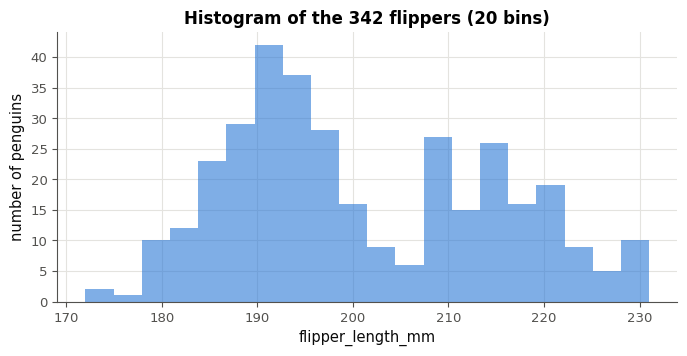

pytest: 14 passed, 103 deselected in 0.79s


In [18]:
st = mylearn.stats
counts_16, edges_16 = st.histogram(flipper, bins=20)
print(counts_16, edges_16.round(1))
print(st.histogram(flipper, bins=7, bin_range=(170, 240)))
density_16, edges_d = st.histogram(flipper, bins=20, density=True)
print("area of the density bars:", np.sum(density_16 * np.diff(edges_d)))
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.stairs(counts_16, edges_16, fill=True, alpha=0.6)
ax.set(xlabel="flipper_length_mm", ylabel="number of penguins", title="Histogram of the 342 flippers (20 bins)")
plt.show()
run_stats_tests("test_histogram_", impl="ref")

**Combien d'intervalles ?** La cellule suivante trace l'histogramme des nageoires avec **ton** `histogram`, pour 4, 20 et 100 intervalles.

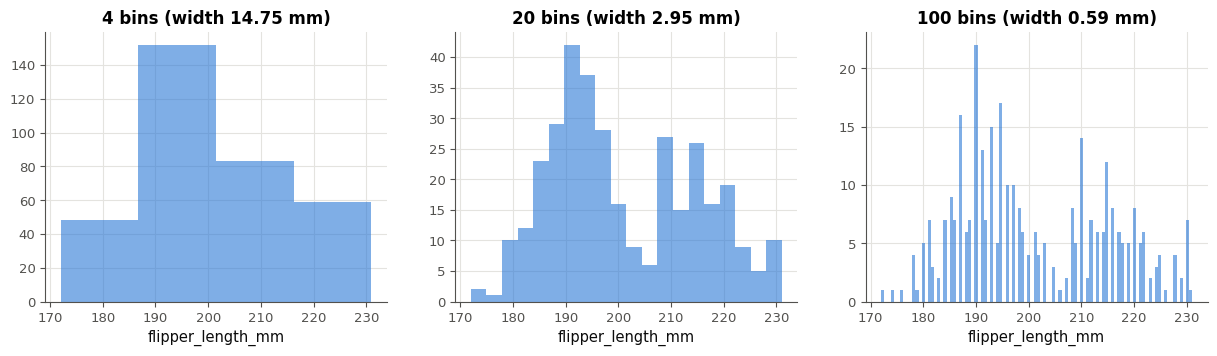

In [19]:
with wb.attempt("2.16"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    for ax, n_bins in zip(axes, [4, 20, 100]):
        counts, edges = mylearn.stats.histogram(flipper, bins=n_bins)
        ax.stairs(counts, edges, fill=True, alpha=0.6)
        ax.set(title=f"{n_bins} bins (width {edges[1] - edges[0]:.2f} mm)", xlabel="flipper_length_mm")
    plt.show()

**Réponses (2.16)** : avec 4 intervalles de près de 15 mm, les deux bosses se fondent en une seule : le creux entre elles (autour de 205 mm) tombe à l'intérieur d'un intervalle (de 201,5 à 216,25 mm). Avec 100 intervalles, chacun ne fait que 0,59 mm, alors que les nageoires sont mesurées au millimètre près (des nombres entiers) : beaucoup d'intervalles ne contiennent aucun entier, d'où les trous du peigne. Un bon choix se situe entre les deux : de 15 à 25 intervalles (2 à 4 mm de large), ou mieux, une largeur multiple de 1 mm, la précision des mesures. Le nombre d'intervalles change ce qu'on voit : on en essaie plusieurs avant de conclure sur la forme d'une distribution.

💡 `np.searchsorted(edges, x, side="right") - 1` est exact sur les bords : il compare aux bords eux-mêmes au lieu de diviser. C'est aussi un premier exemple d'**interface** : ton `histogram` rend exactement ce que rend `np.histogram` (comptages, bords), si bien que `ax.stairs(counts, edges)` trace les deux de la même façon.

### Ex 2.17 — Galerie des lois usuelles 🎨 ★★ ⏱️ 20 min
**Objectif :** tracer les densités et des tirages des lois uniforme, normale, de Bernoulli et catégorielle.  
**Prérequis :** Ex 2.16 · fiche §2.3.1 à §2.3.4 · livre §2.3 (figures 2.6 à 2.12) · **Fil rouge :** synthétique · **Parcours :** C

Le livre montre chaque loi par sa courbe, puis par des tirages : sur sa figure 2.8, chaque tirage est un point posé sous la courbe, décalé verticalement au hasard pour qu'on distingue les points. Reproduis cette idée en une figure de quatre panneaux (2 × 2) :
1. **uniforme** : les densités des lois uniformes sur $[0, 1]$ et sur $[-1, 1]$ ;
2. **normale** : les densités de quatre lois inspirées de la figure 2.7 du livre (qui ne chiffre pas leurs écarts-types), données dans `NORMALS_17` sous la forme $(\mu, \sigma)$ : $\mathcal{N}(0, 1)$, $\mathcal{N}(1, 1)$, $\mathcal{N}(-1, 0{,}5^2)$ et $\mathcal{N}(-1, 2^2)$, avec **30 tirages** de chacune, dessinés comme des points sous les courbes (une couleur par loi) ;
3. **Bernoulli** : pour une pièce équilibrée ($p = 0{,}5$) et la pièce truquée du livre ($p = 0{,}3$), des bâtons pour les probabilités de 0 et de 1, et à côté les fréquences observées sur 1 000 lancers (figure 2.12) ;
4. **catégorielle** : les probabilités des cinq types de voitures de 2.2 (`P_CARS`, `CAR_TYPES`) et les fréquences observées sur 1 000 tirages (ici, `rng.choice(5, size=1000, p=P_CARS)` ; tu écriras ton propre tirage en 2.19).

Écris d'abord deux fonctions de densité, qui acceptent un array `x` :
- `uniform_pdf(x, a, b)` : $\frac{1}{b - a}$ sur $[a, b]$, 0 ailleurs (`np.where`) ;
- `normal_pdf(x, mu, sigma)` : la formule de la fiche §2.3.2 (`np.exp`, `np.sqrt`, `np.pi`).

Puis complète `draw_gallery(rng)`, qui trace la figure avec ces deux fonctions et **un seul** générateur `rng` (la vérification lui passe `np.random.default_rng(0)`). La vérification compare tes densités à celles de SciPy (`scipy.stats.uniform`, `scipy.stats.norm`) ; la figure, elle, se juge à l'œil : compare-la avec celle du corrigé. Titres, légendes et axes font partie du travail.

In [20]:
NORMALS_17 = [(0, 1), (1, 1), (-1, 0.5), (-1, 2)]      # (mu, sigma): four normal laws in the spirit of the book's figure 2.7

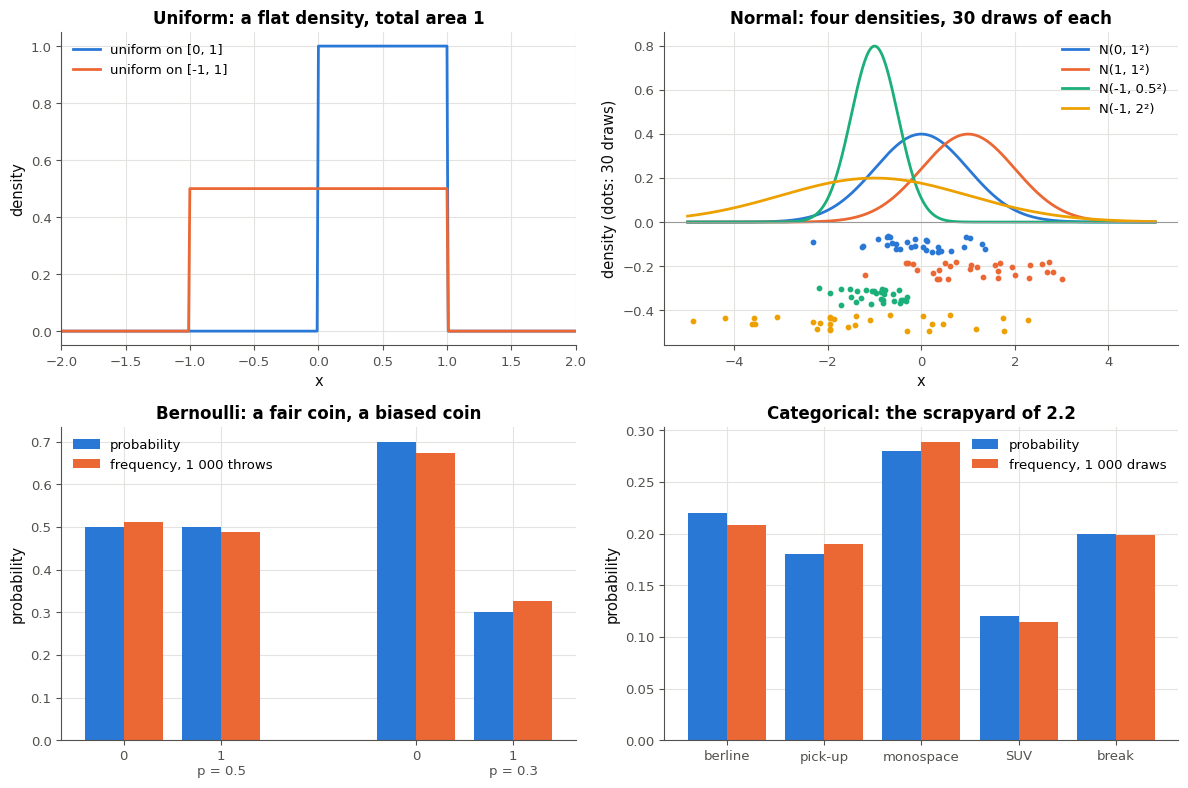

In [21]:
def uniform_pdf(x, a, b):
    """Density of the uniform law on [a, b] at x (x: a number or an array)."""
    x = np.asarray(x, dtype=float)
    return np.where((x >= a) & (x <= b), 1 / (b - a), 0.0)


def normal_pdf(x, mu, sigma):
    """Density of the normal law N(mu, sigma**2) at x (x: a number or an array)."""
    x = np.asarray(x, dtype=float)
    return np.exp(-(x - mu) ** 2 / (2 * sigma ** 2)) / (sigma * np.sqrt(2 * np.pi))


def draw_gallery(rng):
    """The 2 x 2 figure: uniform, normal (+ 30 draws of each), Bernoulli, categorical."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    grid = np.linspace(-5, 5, 1001)
    ax = axes[0, 0]
    for a, b in [(0, 1), (-1, 1)]:
        ax.plot(grid, uniform_pdf(grid, a, b), label=f"uniform on [{a}, {b}]")
    ax.set(xlim=(-2, 2), xlabel="x", ylabel="density", title="Uniform: a flat density, total area 1")
    ax.legend()
    ax = axes[0, 1]
    for k, (mu, sigma) in enumerate(NORMALS_17):
        line, = ax.plot(grid, normal_pdf(grid, mu, sigma), label=f"N({mu}, {sigma}²)")
        draws = rng.normal(mu, sigma, size=30)
        heights = -0.1 - 0.12 * k + rng.uniform(-0.04, 0.04, size=30)   # one row of dots per law, jittered
        ax.scatter(draws, heights, s=10, color=line.get_color())
    ax.axhline(0, color="0.6", lw=0.8)
    ax.set(xlabel="x", ylabel="density (dots: 30 draws)", title="Normal: four densities, 30 draws of each")
    ax.legend()
    ax = axes[1, 0]
    for k, p in enumerate([0.5, 0.3]):
        heads = rng.random(1000) < p                                     # 1 000 throws: True with probability p
        positions = np.array([0, 1]) + 3 * k
        ax.bar(positions - 0.2, [1 - p, p], width=0.4, color="C0", label="probability" if k == 0 else None)
        ax.bar(positions + 0.2, [1 - heads.mean(), heads.mean()], width=0.4, color="C1",
               label="frequency, 1 000 throws" if k == 0 else None)
    ax.set_xticks([0, 1, 3, 4], ["0", "1\np = 0.5", "0", "1\np = 0.3"])
    ax.set(ylabel="probability", title="Bernoulli: a fair coin, a biased coin")
    ax.legend()
    ax = axes[1, 1]
    cars = rng.choice(len(P_CARS), size=1000, p=P_CARS)
    positions = np.arange(len(P_CARS))
    ax.bar(positions - 0.2, P_CARS, width=0.4, label="probability")
    ax.bar(positions + 0.2, np.bincount(cars, minlength=len(P_CARS)) / 1000, width=0.4,
           label="frequency, 1 000 draws")
    ax.set_xticks(positions, CAR_TYPES)
    ax.set(ylabel="probability", title="Categorical: the scrapyard of 2.2")
    ax.legend()
    fig.tight_layout()


draw_gallery(np.random.default_rng(0))
plt.show()

💡 Les tirages se massent là où la densité est haute (panneau 2) : c'est ce que « densité » veut dire. $\mathcal{N}(-1, 0{,}5^2)$ monte jusqu'à 0,8 ; une normale d'écart-type inférieur à 0,4 environ dépasserait 1, et c'est permis, puisque seule l'aire compte. Les fréquences sur 1 000 tirages s'écartent un peu des probabilités : de l'ordre de $\sqrt{p(1 - p)/1\,000}$, soit 1 à 2 points (0B). Aux bornes $a$ et $b$ d'une loi uniforme, la valeur de la densité est une convention (le livre le signale) : la vérification évite ces deux points.

### Ex 2.18 — 68-95-99,7 : la théorie face aux tirages et aux manchots 🔬 ★★ ⏱️ 20 min
**Objectif :** mesurer la part des valeurs à moins de 1, 2 et 3 écarts-types de la moyenne, sur des tirages normaux puis sur de vraies mesures.  
**Prérequis :** Ex 2.15, Ex 2.3 · fiche §2.3.2 · livre §2.3.2 (figures 2.10 et 2.11) · **Fil rouge :** Penguins · **Parcours :** M, C

Écris `share_within(x, k)` : la proportion des valeurs de `x` à **strictement moins** de `k` écarts-types de leur moyenne, $|x_i - \bar{x}| < k\,\sigma$, avec l'écart-type de ddof = 0 (tu peux utiliser NumPy ici). Puis :
a) `shares_normal` : la liste des trois proportions, pour $k = 1, 2, 3$, sur 100 000 tirages `np.random.default_rng(0).standard_normal(100_000)` (3 décimales) ;
b) `shares_adelie` : les mêmes proportions pour les nageoires des 151 Adélie (`adelie_flipper`) : le modèle normal de 2.3 tient-il ?
c) `n_above_203` : combien d'Adélie ont une nageoire de **strictement plus** de 203 mm ? Compare avec ta réponse à 2.3 d ;
d) `shares_all` : les trois proportions pour les nageoires de **tous** les manchots (`flipper`).

La cellule suivante trace les deux histogrammes (en densité) avec la courbe normale de même moyenne et de même écart-type. Réponds ensuite dans la cellule 📝 : pour quelles données la règle marche-t-elle ? Pourquoi échoue-t-elle sur les nageoires de tous les manchots, et dans quel sens ?

In [22]:
adelie_flipper = measured.loc[measured["species"] == "Adelie", "flipper_length_mm"].to_numpy()   # 151 Adelie


def plot_normal_fit(ax, x, title):
    """Density histogram of x, and the normal density with the same mean and standard deviation (ddof=0)."""
    ax.hist(x, bins=20, density=True, alpha=0.6, label="data")
    grid = np.linspace(x.min() - 10, x.max() + 10, 300)
    ax.plot(grid, scipy_stats.norm(x.mean(), x.std()).pdf(grid), label="normal, same mean and std")
    ax.set(title=title, xlabel="flipper_length_mm", ylabel="density")
    ax.legend()

In [23]:
def share_within(x, k):
    """Proportion of the values of x strictly less than k standard deviations (ddof=0) away from their mean."""
    x = np.asarray(x, dtype=float)
    return float(np.mean(np.abs(x - x.mean()) < k * x.std()))


z_18 = np.random.default_rng(0).standard_normal(100_000)
shares_normal = [share_within(z_18, k) for k in (1, 2, 3)]
shares_adelie = [share_within(adelie_flipper, k) for k in (1, 2, 3)]
n_above_203 = int(np.sum(adelie_flipper > 203))
shares_all = [share_within(flipper, k) for k in (1, 2, 3)]
print(np.round(shares_normal, 4), np.round(shares_adelie, 4), n_above_203, np.round(shares_all, 4))
print("largest Adelie flippers:", np.sort(adelie_flipper)[-6:])

[0.684  0.9546 0.9971] [0.7086 0.9536 0.9934] 3 [0.6287 0.9678 1.    ]
largest Adelie flippers: [202. 202. 203. 205. 208. 210.]


In [24]:
wb.record("2.18a", shares_normal, decimals=3)
adelie_ddof1_18 = [float(np.mean(np.abs(adelie_flipper - adelie_flipper.mean()) < k * adelie_flipper.std(ddof=1))) for k in (1, 2, 3)]
wb.record("2.18b", shares_adelie, decimals=3, mistakes={"l'énoncé impose l'écart-type avec ddof = 0": adelie_ddof1_18})
wb.record("2.18c", n_above_203, mistakes={"« strictement plus de 203 mm » : compte les vraies nageoires avec >, pas avec >= (et pas la prévision de 2.3 d)": int(np.sum(adelie_flipper >= 203))})
all_ddof1_18 = [float(np.mean(np.abs(flipper - flipper.mean()) < k * flipper.std(ddof=1))) for k in (1, 2, 3)]
wb.record("2.18d", shares_all, decimals=3, mistakes={"l'énoncé impose l'écart-type avec ddof = 0": all_ddof1_18})

WB_ANSWER {"decimals": 3, "element_coarse": [["2c7f6682e4eed1d750bddb1c9ddbf33cc16790528ec922d69133815d31cf01f3"], ["6168b94387cd09a0d259df427fbcc02bdd97514195f579e8825421816391e0fb"], ["e6ba49dd584eafb9a50d740598571b5a6d84f5a5f7b8203f0a8a57e2dec918f0"]], "element_hashes": ["c134640951d4519e5e446a1ce69ca0488562c925e36d6e388391cdcf9020f4d2", "5031e0dfbae41c43366b4e27c3aba2229d3d5b9812f0e97394e0806d464ef9b6", "a4197752d1083b00c48a47bb7e6b3096c91d7a6a98ac6b5335b9c977eeafb006"], "hash": "4ac7a4e773c5480af8bc1646eb59be50ead9274e1bf3401be0efa3efe434a519", "id": "2.18a", "kind": "array", "shape": [3]}
📝 Ex 2.18a : réponse enregistrée (array, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "element_coarse": [["128c8ad926ed552bfd8a24a149b98bd67142a93b02a3c21075341866799d5e18"], ["01fd88068aade2edd941e9586ede059fda6309ca3094e684f6fc0f3e8874ad47"], ["3c980db66525679eec989721a71bbbffcaf2882e1e2814702b29f461b433fcaa"]], "element_hashes": ["178d78afe176f06a551588a48202c25c5cc3fe822ad5f32c118de4ece3f480ca"

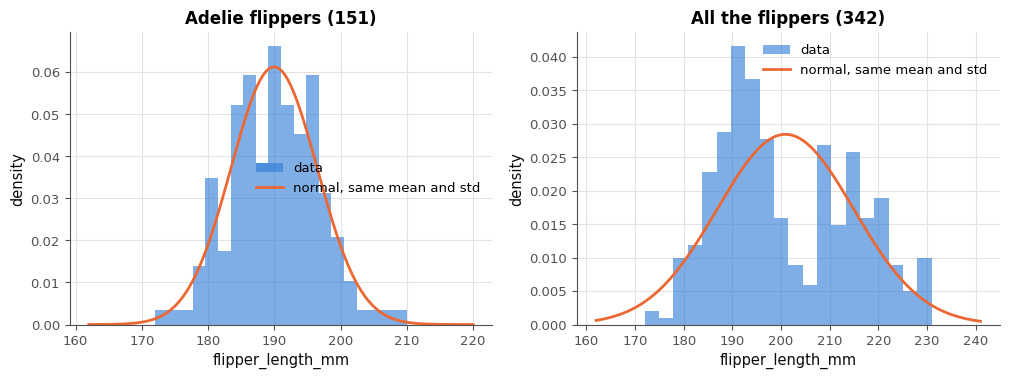

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_normal_fit(axes[0], adelie_flipper, "Adelie flippers (151)")
plot_normal_fit(axes[1], flipper, "All the flippers (342)")
plt.show()

**Réponses (2.18)** : les tirages normaux redonnent la règle, à l'aléa près (68,4 %, 95,5 %, 99,7 %). Les nageoires des Adélie aussi, à peu près (70,9 %, 95,4 %, 99,3 %) : leur histogramme ressemble à une cloche. Le modèle de 2.3 prévoyait environ 4 nageoires au-dessus de 203 mm ; il y en a 3, plus une à 203 mm pile. Sur tous les manchots, la règle se trompe : seulement 62,9 % à moins d'un écart-type, et 100 % à moins de trois. L'histogramme a deux bosses : la moyenne tombe dans le creux entre elles, ce qui vide la bande centrale, et l'écart-type, gonflé par la distance entre les deux groupes, rend la bande de ± 3 écarts-types si large qu'elle contient tout. La règle vaut pour une distribution en cloche : on regarde l'histogramme avant de s'en servir.

💡 Avec ddof = 1, l'écart-type des Adélie grandit un peu (6,54 mm au lieu de 6,52 mm) et une nageoire de plus entre dans la bande de ± 2 écarts-types : 96,0 % au lieu de 95,4 %. Sur 151 valeurs, une seule valeur pèse 0,7 point : ne sur-interprète pas la troisième décimale.

## Partie B · Tirer au hasard : roue, dépendance, avec ou sans remise

Fiche §2.3.4, §2.4 et §2.5. Tu programmes la roue de loterie de la fiche (un tirage dans une loi catégorielle), tu simules une variable qui dépend d'une autre, puis les tirages avec et sans remise, qui serviront au bootstrap.

### Ex 2.19 — La roue de la fortune : tirer dans une distribution discrète 🔨 ★★ ⏱️ 25 min
**Objectif :** tirer dans une loi catégorielle en inversant les sommes cumulées, et comparer les fréquences obtenues aux probabilités.  
**Prérequis :** Ex 2.2, Ex 2.16 · fiche §2.3.4 · livre §2.2 (figures 2.2 à 2.4) · **Fil rouge :** synthétique · **mylearn :** `stats.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/stats.py`, mêmes règles qu'en 2.13 (NumPy permis, sauf les fonctions oracles). Enregistre, puis relance la cellule de vérification.

Écris `sample_categorical(p, size=None, rng=None)` en suivant **exactement** l'algorithme de sa docstring : c'est la roue de la fiche (§2.3.4) et le calcul de 2.2 f et g.
1. Vérifie `p` : une dimension, aucune valeur négative, une somme égale à 1 à $10^{-8}$ près ; sinon, `ValueError`.
2. Si `rng` vaut `None`, crée `np.random.default_rng()` (sans graine : pas reproductible).
3. Tire `u = rng.random(size)`, puis cherche le segment de chaque `u` : `np.searchsorted(np.cumsum(p), u, side="right")`.
4. Ramène le résultat à `len(p) - 1` au plus (`np.minimum`) : à cause des arrondis, la dernière somme cumulée peut valoir `0.9999999999999999`, et un `u` plus grand donnerait une catégorie qui n'existe pas.
5. Avec `size=None`, renvoie un `int` Python (`int(...)`), sinon un array d'entiers.

La vérification tire 10 000 voitures dans la casse de 2.2 (`P_CARS`) avec la graine 0, compare les fréquences observées aux probabilités, vérifie qu'un tirage unique renvoie un `int`, trace les deux en bâtons, puis lance les tests : ils vérifient aussi qu'à graine égale, tes tirages sont **exactement** ceux de l'algorithme documenté.

probabilities: [0.22 0.18 0.28 0.12 0.2 ] · frequencies: [0.222 0.178 0.28  0.118 0.202] · first draws: [2 1 0 0 4 4 2 3 2 4]
one draw: 2


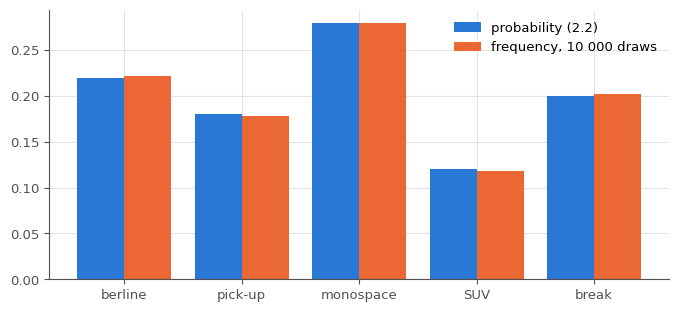

pytest: 7 passed, 110 deselected in 0.72s


In [26]:
st = mylearn.stats
cars_19 = st.sample_categorical(P_CARS, size=10_000, rng=np.random.default_rng(0))
freq_19 = np.bincount(cars_19, minlength=len(P_CARS)) / len(cars_19)
print("probabilities:", P_CARS.round(3), "· frequencies:", freq_19.round(3), "· first draws:", cars_19[:10])
print("one draw:", st.sample_categorical(P_CARS, rng=np.random.default_rng(1)))
positions_19 = np.arange(len(P_CARS))
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(positions_19 - 0.2, P_CARS, width=0.4, label="probability (2.2)")
ax.bar(positions_19 + 0.2, freq_19, width=0.4, label="frequency, 10 000 draws")
ax.set_xticks(positions_19, CAR_TYPES)
ax.legend()
plt.show()
run_stats_tests("test_sample_categorical_", impl="ref")

💡 Sur 10 000 tirages, les fréquences s'écartent des probabilités de quelques dixièmes de point (0,2 point au plus ici) : l'écart typique vaut $\sqrt{p(1 - p)/n}$, environ 0,45 point pour $p = 0{,}28$. `np.searchsorted` trouve le segment de chaque `u` par dichotomie, en $\log_2 K$ comparaisons pour $K$ catégories. Un modèle de langage fait lui aussi un tirage dans une loi catégorielle, sur des dizaines de milliers de tokens (ch. 22 et B3), même si PyTorch utilise une autre astuce de tirage. `rng.choice(K, p=p)` fait la même chose en NumPy.

### Ex 2.20 — Le pelage des animaux : une variable qui dépend d'une autre 🔮 ★★ ⏱️ 15 min
**Objectif :** prévoir puis simuler une variable dont la loi dépend d'une autre, et voir ce que change l'indépendance.  
**Prérequis :** Ex 2.19 · fiche §2.3.5, §2.4, §2.4.1 · livre §2.4 · **Fil rouge :** synthétique · **Parcours :** C

Le livre (§2.4) tire d'abord un animal, puis la longueur de son pelage dans la loi propre à cet animal. Voici le modèle :

| Animal | Probabilité | Pelage (cm) |
|---|---|---|
| chien | 0,5 | loi normale de moyenne 7 et d'écart-type 0,8 |
| chat | 0,3 | loi normale de moyenne 3 et d'écart-type 0,4 |
| hamster | 0,2 | loi normale de moyenne 1 et d'écart-type 0,2 |

**Sans rien exécuter**, prévois :
a) `pred_mean_fur` : la longueur moyenne du pelage sur un très grand nombre d'animaux tirés (1 décimale) ; pense à l'espérance (fiche §2.3.5) ;
b) `pred_bumps` : le nombre de bosses de l'histogramme de tous les pelages (un entier) ;
c) `pred_above_7` : la probabilité qu'un animal tiré au hasard ait un pelage de plus de 7 cm (2 décimales) ;
d) `pred_above_7_dog` : la même probabilité, **sachant** que l'animal tiré est un chien (2 décimales).

Comparer c et d, c'est voir la dépendance : connaître l'animal change la loi du pelage. Écris ton hypothèse, puis tes quatre prédictions ; ensuite seulement, exécute l'**Expérience** : elle tire 20 000 animaux avec ton `sample_categorical` (2.19), puis leurs pelages.

In [27]:
ANIMALS = ["dog", "cat", "hamster"]
P_ANIMALS = np.array([0.5, 0.3, 0.2])        # step 1: which animal?
FUR_MEAN = np.array([7.0, 3.0, 1.0])         # step 2: its fur length (cm), drawn from the normal law of its animal
FUR_STD = np.array([0.8, 0.4, 0.2])
animal_20 = fur_20 = None                    # filled by the experiment below

In [28]:
pred_mean_fur = 0.5 * 7 + 0.3 * 3 + 0.2 * 1     # the expected value: 4.6 cm
pred_bumps = 3
pred_above_7 = 0.5 * 0.5                         # a dog (0.5), whose fur is above its mean (0.5)
pred_above_7_dog = 0.5

In [29]:
wb.record("2.20a", pred_mean_fur, decimals=1, mistakes={"pondère chaque moyenne par la probabilité de l'animal (ce n'est pas la moyenne simple de 7, 3 et 1)": 11 / 3})
wb.record("2.20b", pred_bumps, mistakes={"compare les intervalles moyenne ± 3 écarts-types des trois animaux : se chevauchent-ils ?": 1})
wb.record("2.20c", pred_above_7, decimals=2, mistakes={"tu as raisonné comme si l'animal était forcément un chien : ici, il peut être n'importe lequel ; combine la probabilité de tirer chaque animal et celle que son pelage dépasse 7 cm": 0.5})
wb.record("2.20d", pred_above_7_dog, decimals=2, mistakes={"sachant que c'est un chien, ne multiplie plus par la probabilité de tirer un chien : seule compte la loi de son pelage": 0.25})

WB_ANSWER {"decimals": 1, "hash": "b54131936ec8d5576f61cf536dbb19ce45720e83e46021b23768456c35f9cc47", "hash_coarse": "9477c45ec8a24a078a639ced83dfbe85f3687eac847b55b43d7510a8e88640d9", "id": "2.20a", "kind": "float", "magnitude": 0, "mistakes": {"dc450b51e7b1b2efc7213cd9e3220795b1bf643c908cc11868998880654e6fb7": "pondère chaque moyenne par la probabilité de l'animal (ce n'est pas la moyenne simple de 7, 3 et 1)"}, "sign": 1}
📝 Ex 2.20a : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"hash": "4d6a61541448974a89733746aa0afc47f4ac947f7139bf6c4f2957e18df51cb5", "id": "2.20b", "kind": "int", "magnitude": 0, "mistakes": {"b3514d55682f94bb740bd237d6e861dbb8aa05744492da0dee0102bb3858fdda": "compare les intervalles moyenne ± 3 écarts-types des trois animaux : se chevauchent-ils ?"}, "sign": 1}
📝 Ex 2.20b : réponse enregistrée (int).
WB_ANSWER {"alt_coarse": ["03de80724920bc0fe626fc67bef9fc29068d67f5a7491cc5425557871ccd2a35"], "decimals": 2, "hash": "aa362a360cf9ee83185d436efe0d89378158

**Expérience** : exécute la cellule et compare avec tes prédictions.

mean fur: 4.58 cm · P(fur > 7 cm) ≈ 0.249 · P(fur > 7 cm | dog) ≈ 0.502


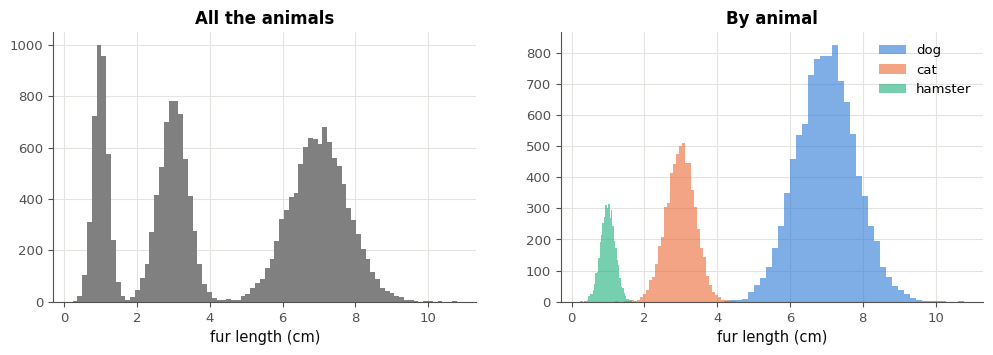

In [30]:
if any(answer is ... or answer is None for answer in [pred_mean_fur, pred_bumps, pred_above_7, pred_above_7_dog]):
    print("⏳ Ex 2.20 : écris d'abord tes quatre prédictions, puis relance cette cellule.")
else:
    with wb.attempt("2.20"):
        rng_20 = np.random.default_rng(0)
        animal_20 = mylearn.stats.sample_categorical(P_ANIMALS, size=20_000, rng=rng_20)   # step 1: the animals
        fur_20 = rng_20.normal(FUR_MEAN[animal_20], FUR_STD[animal_20])                   # step 2: each fur, given its animal
        print(f"mean fur: {fur_20.mean():.2f} cm · P(fur > 7 cm) ≈ {np.mean(fur_20 > 7):.3f} · "
              f"P(fur > 7 cm | dog) ≈ {np.mean(fur_20[animal_20 == 0] > 7):.3f}")
        fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
        axes[0].hist(fur_20, bins=80, color="0.5")
        axes[0].set_title("All the animals")
        for k, name in enumerate(ANIMALS):
            axes[1].hist(fur_20[animal_20 == k], bins=40, alpha=0.6, label=name)
        axes[1].set_title("By animal")
        axes[1].legend()
        for ax in axes:
            ax.set_xlabel("fur length (cm)")
        plt.show()

e) On mélange maintenant les pelages au hasard, sans toucher aux animaux (`rng.permutation(fur_20)`) : chaque animal reçoit le pelage d'un animal quelconque, et les deux colonnes deviennent **indépendantes**. Prévois, **avant** d'exécuter la cellule d'après, `pred_hamster_shuffled` : la longueur moyenne du pelage des « hamsters » après ce mélange (1 décimale).

In [31]:
pred_hamster_shuffled = 4.6   # after shuffling, a hamster gets the fur of any animal: the overall mean

In [32]:
wb.record("2.20e", pred_hamster_shuffled, decimals=1, mistakes={"le mélange sépare chaque pelage de son animal : un « hamster » reçoit maintenant le pelage d'un animal quelconque": 1.0})

WB_ANSWER {"decimals": 1, "hash": "00b1d89853cc37dc82a7606dcb1f91c2d6f8e02ee0edb5abc82d8479eec869df", "hash_coarse": "cd5295c420796290a8c5de457147fb9acbb5daf05f5aea0b0e81e84e077077a0", "id": "2.20e", "kind": "float", "magnitude": 0, "mistakes": {"a1c66b96e26719c2656d020ac96767d60e51e47ac7e7bdb706ed4ce4d858e2e2": "le mélange sépare chaque pelage de son animal : un « hamster » reçoit maintenant le pelage d'un animal quelconque"}, "sign": 1}
📝 Ex 2.20e : réponse enregistrée (float, 1 décimale(s)).


mean fur of the hamsters: 1.00 cm before shuffling, 4.57 cm after


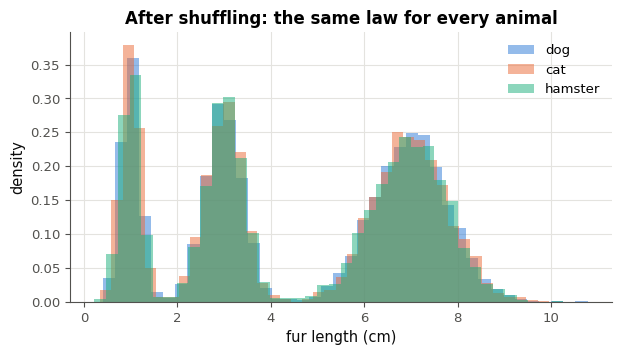

In [33]:
if any(answer is ... or answer is None for answer in [pred_hamster_shuffled]):
    print("⏳ Ex 2.20 : écris d'abord ta prédiction e), puis relance cette cellule.")
else:
    if fur_20 is None:
        print("⏳ Ex 2.20 : exécute d'abord l'expérience de a) à d) (elle utilise ton sample_categorical de 2.19).")
    else:
        shuffled_fur_20 = np.random.default_rng(1).permutation(fur_20)     # the furs, in a random order
        print(f"mean fur of the hamsters: {fur_20[animal_20 == 2].mean():.2f} cm before shuffling, "
              f"{shuffled_fur_20[animal_20 == 2].mean():.2f} cm after")
        fig, ax = plt.subplots(figsize=(7, 3.5))
        for k, name in enumerate(ANIMALS):
            ax.hist(shuffled_fur_20[animal_20 == k], bins=40, alpha=0.5, density=True, label=name)
        ax.set(title="After shuffling: the same law for every animal", xlabel="fur length (cm)", ylabel="density")
        ax.legend()
        plt.show()

💡 $\mathbb{E}[\text{pelage}] = 0{,}5 \times 7 + 0{,}3 \times 3 + 0{,}2 \times 1 = 4{,}6$ cm : l'espérance pondère la moyenne de chaque animal par sa probabilité. Les trois bosses ne se chevauchent pas (hamster : de 0,4 à 1,6 cm ; chat : de 1,8 à 4,2 cm ; chien : de 4,6 à 9,4 cm, à ± 3 écarts-types). $P(\text{pelage} > 7) = 0{,}25$ mais $P(\text{pelage} > 7 \mid \text{chien}) = 0{,}5$ : connaître l'animal change la loi du pelage, les deux variables sont **dépendantes**. Les couples (animal, pelage) successifs sont pourtant **i.i.d.** : chaque tirage recommence à zéro, avec la même loi (fiche §2.4.1). Après le mélange, chaque « hamster » porte le pelage d'un animal quelconque : sa moyenne devient 4,6 cm, et les trois histogrammes se superposent. C'est exactement ce que veut dire l'indépendance : connaître l'animal n'apprend plus rien sur le pelage. Les probabilités « sachant que » sont le sujet des ch. 3 et 4.

### Ex 2.21 — Tirer avec ou sans remise 🔨 ★★ ⏱️ 20 min
**Objectif :** écrire les tirages avec et sans remise, et les reconnaître dans les usages du ML (mini-batches, bootstrap).  
**Prérequis :** Quiz 2.Q9 · 0A (mini-batches) · fiche §2.5 · livre §2.5 (figures 2.13 et 2.14) · **Fil rouge :** synthétique · **mylearn :** `stats.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/stats.py`, mêmes règles qu'en 2.13 (NumPy permis, sauf les fonctions oracles). Enregistre, puis relance la cellule de vérification.

Écris `sample(population, size, replace=True, rng=None)` en suivant l'algorithme de sa docstring : convertis la population en array (`np.asarray`), puis choisis des **indices** de lignes :
- **avec remise** : `rng.integers(0, n, size)` (chaque tirage choisit parmi les $n$ éléments) ;
- **sans remise** : les `size` premiers éléments d'une permutation, `rng.permutation(n)[:size]` ;

et renvoie `population[indices]`. Refuse une taille négative, une population vide, ou plus de tirages que d'éléments sans remise (`ValueError`). Si `rng` vaut `None`, crée `np.random.default_rng()`.

Vérifications, avec les huit lettres `LETTERS` (les huit objets des figures 2.13 et 2.14 du livre) ; la cellule de vérification les calcule avec ta fonction :
a) `"".join(sample(LETTERS, 8, rng=np.random.default_rng(1)))` : huit tirages **avec** remise ;
b) le nombre de lettres **distinctes** dans ce tirage ;
c) `"".join(sample(LETTERS, 8, replace=False, rng=np.random.default_rng(1)))` : la même chose **sans** remise ;
d) le nom de l'exception levée par `sample(LETTERS, 10, replace=False)`.

Puis deux usages du ML, à écrire avec **ta** fonction `sample` :
- `epoch_minibatches(n_examples, batch_size, rng)` : les mini-batches d'une epoch (0A), sous forme de **liste** d'arrays : un ordre au hasard des indices `0, …, n_examples − 1`, tiré **sans** remise, puis découpé en morceaux consécutifs de `batch_size` (le dernier peut être plus court). e) La vérification l'appelle pour 10 exemples, des mini-batches de 4 et `rng = np.random.default_rng(0)`, et vérifie le **deuxième** mini-batch.
- `mean_share_distinct(n_resamples, n, rng)` : la part moyenne d'éléments **distincts** dans `n_resamples` rééchantillons de `n` tirages **avec** remise parmi `np.arange(n)`, tous tirés avec le même générateur `rng`. f) La vérification l'appelle pour 200 rééchantillons de 1 000, avec `np.random.default_rng(0)` (3 décimales) : compare avec 2.6 h.

In [34]:
LETTERS = list("ABCDEFGH")   # the pool of eight objects of the book's figures 2.13 and 2.14

In [35]:
def epoch_minibatches(n_examples, batch_size, rng):
    """The mini-batches of one epoch: a random order of the indices 0, ..., n_examples - 1, drawn WITHOUT
    replacement with YOUR mylearn.stats.sample, cut into consecutive pieces of batch_size (a list of arrays)."""
    order = mylearn.stats.sample(np.arange(n_examples), n_examples, replace=False, rng=rng)
    return [order[start:start + batch_size] for start in range(0, n_examples, batch_size)]


def mean_share_distinct(n_resamples, n, rng):
    """Mean share of distinct elements in n_resamples resamples of n draws WITH replacement among np.arange(n)
    (YOUR mylearn.stats.sample, the same generator rng for all the resamples)."""
    population = np.arange(n)
    shares = [len(np.unique(mylearn.stats.sample(population, n, rng=rng))) / n for _ in range(n_resamples)]
    return float(np.mean(shares))


st = mylearn.stats
drawn_21 = st.sample(LETTERS, 8, rng=np.random.default_rng(1))
print("with replacement:", "".join(drawn_21), "·", len(set(drawn_21)), "distinct letters")
print("without replacement:", "".join(st.sample(LETTERS, 8, replace=False, rng=np.random.default_rng(1))))
print("10 draws without replacement among 8:", error_name(st.sample, LETTERS, 10, replace=False))
batches_21 = epoch_minibatches(10, 4, np.random.default_rng(0))
share_21 = mean_share_distinct(200, 1000, np.random.default_rng(0))
print("mini-batches:", [batch.tolist() for batch in batches_21], "· mean share of distinct elements:", share_21)
run_stats_tests("test_sample_ and not categorical", impl="ref")

with replacement: DEGHABGH · 6 distinct letters
without replacement: FABECGDH
10 draws without replacement among 8: ValueError
mini-batches: [[4, 6, 2, 7], [3, 5, 9, 0], [8, 1]] · mean share of distinct elements: 0.6329899999999999


pytest: 8 passed, 109 deselected in 0.76s


In [36]:
wb.record("2.21a", "".join(drawn_21))
wb.record("2.21b", len(set(drawn_21)), mistakes={"compte les lettres DIFFÉRENTES, pas les tirages": 8})
wb.record("2.21c", "".join(st.sample(LETTERS, 8, replace=False, rng=np.random.default_rng(1))),
          mistakes={"sans remise, l'algorithme documenté prend le début de rng.permutation(n) ; rng.choice(…, replace=False) ne tire pas de la même façon": "".join(np.random.default_rng(1).choice(LETTERS, 8, replace=False))})
wb.record("2.21d", error_name(st.sample, LETTERS, 10, replace=False),
          mistakes={"sans remise, on ne peut pas tirer plus d'éléments qu'il n'y en a : ta fonction doit le refuser": "no error"})
wb.record("2.21e", batches_21[1])
wb.record("2.21f", share_21, decimals=3, mistakes={"c'est la part des éléments ABSENTS : on demande celle des éléments présents au moins une fois": 1 - share_21,
                                                   "c'est la valeur théorique de 2.6 h : on demande la moyenne de TES 200 rééchantillons": 1 - (1 - 1 / 1000) ** 1000})

WB_ANSWER {"hash": "f25fda8e916b8a25178b23815d9756c7b390bcd0637ef5b4e772e188dc104cfb", "id": "2.21a", "kind": "str"}
📝 Ex 2.21a : réponse enregistrée (str).
WB_ANSWER {"hash": "e29ddd0777fc34ce48759c9ea8a429e8c94df3b2a513c89815bf539de701e32f", "id": "2.21b", "kind": "int", "magnitude": 0, "mistakes": {"4f3bf03c3ac4dfab74ea0db895a02c44b17aa0e0ab35987d543c8eeaaa8b763b": "compte les lettres DIFFÉRENTES, pas les tirages"}, "sign": 1}
📝 Ex 2.21b : réponse enregistrée (int).
WB_ANSWER {"hash": "60f3e160512b5ed5965c8dc78cd84b779193f367d453f78ef9cf42215b3ac437", "id": "2.21c", "kind": "str", "mistakes": {"db9feaffcea1ecd11d1aa7864d8d53bbb903341d4e61f78bb70ea5a197a83032": "sans remise, l'algorithme documenté prend le début de rng.permutation(n) ; rng.choice(…, replace=False) ne tire pas de la même façon"}}
📝 Ex 2.21c : réponse enregistrée (str).
WB_ANSWER {"hash": "139292b2e0f258cb96bb6b676de37dfd7696d7196f83629d6d3454b34a910d35", "id": "2.21d", "kind": "str", "mistakes": {"0b56bae69893f1faad39

💡 Avec remise, huit tirages parmi huit lettres n'en donnent que 6 différentes : G et H sortent deux fois, C et F sont absentes. Sans remise, on obtient une **permutation** : chaque lettre une fois. Une epoch est un tirage sans remise (chaque exemple est vu une fois), découpé en mini-batches ; un rééchantillon bootstrap est un tirage avec remise, qui contient en moyenne $1 - (1 - 1/n)^n \approx 63{,}2$ % d'éléments distincts (2.6 h) ; ta simulation de f donne 0,633, à l'aléa près. Remarque : `rng.choice(LETTERS, 8)` redonne exactement a (NumPy tire aussi des indices avec `integers`), mais pas c : sans remise, `rng.choice` n'utilise pas `permutation(n)[:size]`. Deux méthodes correctes peuvent donc donner des tirages différents à graine égale : c'est pourquoi la docstring impose l'algorithme.

## Partie C · Le bootstrap et son intervalle de confiance

Fiche §2.6. Tu programmes le bootstrap et tu l'appliques à la masse des manchots Chinstrap ; puis tu mets à l'épreuve la recette du livre (des rééchantillons de 20) et tu compares tes intervalles avec l'outil professionnel, `scipy.stats.bootstrap`.

In [37]:
chinstrap_mass = measured.loc[measured["species"] == "Chinstrap", "body_mass_g"].to_numpy()   # 68 penguins


def plot_bootstrap(boot, estimate, ci, title, xlabel):
    """Histogram of bootstrap values, with the estimate (dashed line) and the interval (shaded)."""
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(boot, bins=30, color="0.6")
    ax.axvspan(ci[0], ci[1], alpha=0.2, label=f"interval [{ci[0]:.1f}, {ci[1]:.1f}]")
    ax.axvline(estimate, ls="--", color="black", label=f"estimate {estimate:.1f}")
    ax.set(title=title, xlabel=xlabel, ylabel="number of resamples")
    ax.legend()
    plt.show()


def check_widths_23(widths):
    """Verdict of 2.23 (widths for SIZES_23)."""
    widths = np.asarray(widths, dtype=float)
    ok = widths.shape == (len(SIZES_23),) and bool(np.all(np.diff(widths) < 0)) and 25 < widths[-1] < 45
    verdict("2.23", ok, "tes largeurs sont mesurées : lis le graphique, puis réponds dans la cellule 📝.",
            "tes largeurs ne sont pas celles attendues : ci_width doit renvoyer la largeur de l'intervalle à 80 %, "
            "avec des rééchantillons de la taille demandée (vérifie confidence et sample_size).")


def check_coverage_23(cover_20, cover_500):
    """Verdict of 2.23 (coverage of the two recipes)."""
    verdict("2.23", cover_20 > 0.95 and 0.65 <= cover_500 <= 0.93,
            "tes deux couvertures sont mesurées : compare-les à la promesse de 80 % (cellule 📝).",
            "couvertures inattendues : relis coverage (à chaque enquête, un NOUVEL échantillon de 500 valeurs tiré "
            "sans remise, puis son intervalle à 80 %).")


def check_n_boot_23(widths):
    """Verdict of 2.23 (widths for 100, 1 000 and 10 000 resamples)."""
    widths = np.asarray(widths, dtype=float)
    ok = len(set(np.round(widths, 9))) == 3 and widths.max() / widths.min() < 1.3
    verdict("2.23", ok, "tu as les trois largeurs : réponds dans la cellule 📝.",
            "ci_width doit utiliser son argument n_boot (et transmettre le même générateur) : relis-la.")

### Ex 2.22 — Bootstrap : distribution et intervalle de confiance 🔨 ★★ ⏱️ 30 min
**Objectif :** programmer le bootstrap et en tirer un intervalle de confiance percentile.  
**Prérequis :** Ex 2.21, Ex 2.15 · 0A (`Callable`, arguments après `*`) · fiche §2.6 (🧮 intervalle de confiance) · livre §2.6 (figures 2.17 et 2.18) · **Fil rouge :** Penguins · **mylearn :** `stats.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/stats.py`, mêmes règles qu'en 2.13 (NumPy permis, sauf les fonctions oracles). Enregistre, puis relance la cellule de vérification.

Écris les deux fonctions du bootstrap.
- `bootstrap_distribution(x, statistic=np.mean, *, n_boot=1000, sample_size=None, rng=None)` : pour chaque rééchantillon, **dans l'ordre**, tire les indices `idx = rng.integers(0, n, size=sample_size)` (avec remise), puis calcule `statistic(x[idx])` ; renvoie les `n_boot` valeurs dans un array. `sample_size=None` veut dire $n$, la taille de `x`. L'étoile `*` de la signature oblige à nommer les arguments qui la suivent (`n_boot=500`, pas `500`) : on ne peut plus les confondre (0A.40). `statistic` est une fonction : `np.mean`, `np.median`, ou la tienne.
- `bootstrap_ci(x, statistic=np.mean, *, confidence=0.95, n_boot=1000, sample_size=None, rng=None)` : réutilise `bootstrap_distribution` avec les mêmes arguments, puis coupe $\frac{1 - c}{2}$ des valeurs de chaque côté, avec $c$ = `confidence` : les bornes sont les percentiles $50\,(1 - c)$ et $50\,(1 + c)$ de la distribution (ta fonction `percentile`). Renvoie un tuple de deux `float` ; refuse `confidence` hors de $]0, 1[$.

Vérifications, sur la masse des 68 manchots Chinstrap (`chinstrap_mass`), chaque appel avec **son** générateur `rng=np.random.default_rng(0)` (la cellule de vérification les calcule avec tes fonctions) :
a) la masse moyenne de l'échantillon (1 décimale) ;
b) l'intervalle de confiance à 95 % de la moyenne, `[bas, haut]` (1 décimale) ;
c) l'intervalle à 80 %, comme dans le livre (figure 2.18) ;
d) l'intervalle à 95 % de la **médiane** (`statistic=np.median`) ;
e) l'écart-type (ddof = 0) de la distribution bootstrap de la moyenne (1 décimale) : c'est l'**erreur type** (*standard error*), la dispersion de la moyenne d'un échantillon à l'autre.

La vérification trace ensuite l'histogramme des 1 000 moyennes, avec la moyenne de l'échantillon et l'intervalle à 95 % (l'équivalent des figures 2.17 et 2.18 du livre), puis lance les tests.

sample mean: 3733.0882352941176 · 95 %: (3647.4172794117644, 3822.444852941176) · 80 %: (3676.1029411764707, 3790.1102941176473)
95 % interval of the median: (3650.0, 3800.0)
standard error: 45.35731515491503 · classical formula s / sqrt(n): 46.607474593816185


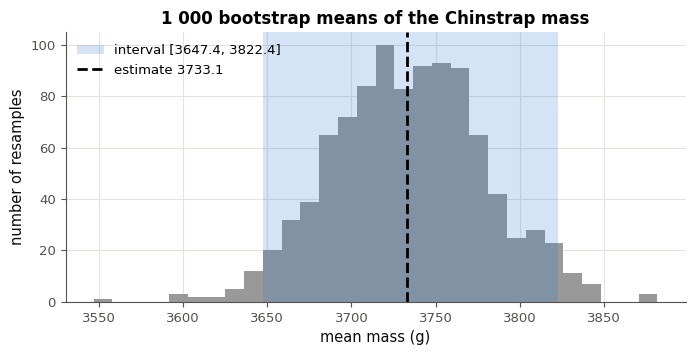

pytest: 16 passed, 101 deselected in 1.16s


In [38]:
st = mylearn.stats
ci_22 = st.bootstrap_ci(chinstrap_mass, rng=np.random.default_rng(0))
boot_22 = st.bootstrap_distribution(chinstrap_mass, rng=np.random.default_rng(0))
print("sample mean:", st.mean(chinstrap_mass), "· 95 %:", ci_22,
      "· 80 %:", st.bootstrap_ci(chinstrap_mass, confidence=0.8, rng=np.random.default_rng(0)))
print("95 % interval of the median:", st.bootstrap_ci(chinstrap_mass, np.median, rng=np.random.default_rng(0)))
print("standard error:", st.std(boot_22), "· classical formula s / sqrt(n):",
      st.std(chinstrap_mass, ddof=1) / np.sqrt(len(chinstrap_mass)))
plot_bootstrap(boot_22, st.mean(chinstrap_mass), ci_22, "1 000 bootstrap means of the Chinstrap mass", "mean mass (g)")
run_stats_tests("test_bootstrap_", impl="ref")

In [39]:
wb.record("2.22a", st.mean(chinstrap_mass), decimals=1)
wb.record("2.22b", ci_22, decimals=1, mistakes={"c'est l'intervalle à 80 % : confidence vaut 0,95 par défaut": st.bootstrap_ci(chinstrap_mass, confidence=0.8, rng=np.random.default_rng(0)),
                                                "pour 95 %, coupe 2,5 % de CHAQUE côté : les percentiles 2,5 et 97,5 (pas 5 et 95)": st.bootstrap_ci(chinstrap_mass, confidence=0.9, rng=np.random.default_rng(0))})
wb.record("2.22c", st.bootstrap_ci(chinstrap_mass, confidence=0.8, rng=np.random.default_rng(0)), decimals=1,
          mistakes={"pour 80 %, coupe 10 % de CHAQUE côté : les percentiles 10 et 90 (pas 20 et 80)": st.bootstrap_ci(chinstrap_mass, confidence=0.6, rng=np.random.default_rng(0))})
wb.record("2.22d", st.bootstrap_ci(chinstrap_mass, np.median, rng=np.random.default_rng(0)), decimals=1)
wb.record("2.22e", st.std(boot_22), decimals=1, mistakes={"c'est l'écart-type des 68 MASSES : on demande celui des 1 000 moyennes bootstrap": st.std(chinstrap_mass)})

WB_ANSWER {"decimals": 1, "hash": "0635d910e9beffc5c4aaaf547155023138cf04da1efd89fbc5606903642ab556", "hash_coarse": "de855b868d5380fa585aacebb4b15da095848128ba152e85dc217d7c109234f7", "id": "2.22a", "kind": "float", "magnitude": 3, "sign": 1}
📝 Ex 2.22a : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 1, "element_hashes": ["d9d34e6e66498125d8a35c26ba2f59e5e501b4c92255d8e1db03ddf32ea313b4", "2faf9b9db93de5bd8c06a5695ff3467941f428fa34c423cdc95484f22801cdc8"], "hash": "a6b55793e2cb120b3eae8986d34c86a5f81180d996bd5e7a4dbbb95cb9e6c613", "id": "2.22b", "kind": "array", "mistakes": {"a286c44692ee6ede48fc17be6d6788b811130f9c0a9e2a7830086249821fbf45": "c'est l'intervalle à 80 % : confidence vaut 0,95 par défaut", "f7571a253c8258146a9e5e4dac4caa8c9c561415f4b898fea2c210b953c5b53f": "pour 95 %, coupe 2,5 % de CHAQUE côté : les percentiles 2,5 et 97,5 (pas 5 et 95)"}, "shape": [2]}
📝 Ex 2.22b : réponse enregistrée (array, 1 décimale(s)).
WB_ANSWER {"decimals": 1, "element_hashe

💡 À 95 %, la masse moyenne des Chinstrap est comprise entre 3 647 et 3 822 g environ : la moyenne de l'échantillon (3 733 g) est connue à ± 90 g près. L'intervalle à 80 % est plus étroit : il promet moins. Celui de la médiane va de 3 650 à 3 800 g, des valeurs « rondes », parce que la médiane de masses arrondies à 25 g est elle-même arrondie. L'erreur type (45,4 g) est proche de la formule classique $s / \sqrt{n}$ (46,6 g, avec ddof = 1), que tu croiseras dans tout cours de statistique ; avec une infinité de rééchantillons, le bootstrap donnerait exactement l'écart-type **à ddof = 0** divisé par $\sqrt{n}$, soit 46,3 g. Il retrouve ce résultat sans formule, et marche aussi pour une médiane ou une corrélation.

### Ex 2.23 — Bootstraps de 20 (livre) ou de n (aujourd'hui) ? 🔬 ★★ ⏱️ 30 min
**Objectif :** mesurer l'effet de la taille des rééchantillons sur l'intervalle, et vérifier lequel tient sa promesse.  
**Prérequis :** Ex 2.22 · fiche §2.6 (🕰️ taille des rééchantillons, 🧮 intervalle de confiance) · livre §2.6 · **Fil rouge :** synthétique · **Parcours :** M, C

Le livre (§2.6) part d'une population de 5 000 entiers de 0 à 1 000, en tire un échantillon de 500, puis fait 1 000 rééchantillons de **20** éléments seulement, et lit un intervalle à 80 %. La pratique actuelle prend des rééchantillons de la taille de l'échantillon, ici 500. Refais l'expérience avec la `population` et l'échantillon `sample_23` fournis : on connaît donc la vraie moyenne, `population.mean()`, ce qui n'arrive jamais en vrai.

Écris, avec tes fonctions de `mylearn.stats` :
1. `ci_width(sample_size, rng, n_boot=1000)` : la largeur (haut − bas) de l'intervalle à 80 % de la moyenne de `sample_23`, avec `n_boot` rééchantillons de taille `sample_size` ;
2. `widths_by_size()` : la liste des largeurs pour chaque taille de `SIZES_23` (de 5 à 500), chaque fois avec `np.random.default_rng(1)` ;
3. `coverage(sample_size, n_repeats, rng)` : la proportion d'intervalles à 80 % qui contiennent la vraie moyenne quand on refait **toute** l'enquête `n_repeats` fois. À chaque fois : un nouvel échantillon de 500 valeurs tiré **sans** remise dans `population` (ton `sample`, 2.21), puis son intervalle bootstrap à 80 %, avec 500 rééchantillons de taille `sample_size` ; le même générateur `rng` sert à tout. Un intervalle « à 80 % » honnête doit contenir la vraie valeur environ 80 fois sur 100 (fiche, 🧮) : cette proportion s'appelle la **couverture** (*coverage*) de la méthode.

La vérification affiche les largeurs et le rapport des largeurs (20 contre 500), trace la largeur selon la taille en échelle logarithmique, mesure la couverture des deux recettes, puis compare 100, 1 000 et 10 000 rééchantillons de taille 500. Réponds dans la cellule 📝 :
- De combien l'intervalle du livre est-il trop large ? Comment la largeur varie-t-elle avec la taille des rééchantillons (quand la taille est multipliée par 4) ?
- Laquelle des deux recettes tient sa promesse de 80 % ?
- Augmenter le **nombre** de rééchantillons rétrécit-il l'intervalle ? Que change-t-il ?

In [40]:
rng_23 = np.random.default_rng(2023)
population = rng_23.integers(0, 1001, size=5000)            # 5 000 integers from 0 to 1 000 (book, §2.6)
sample_23 = population[rng_23.permutation(5000)[:500]]      # a sample of 500 values, drawn without replacement
SIZES_23 = [5, 10, 20, 50, 100, 200, 500]
N_REPEATS_23 = 100 if FAST_MODE else 400                    # number of surveys redone for the coverage
print(f"true mean of the population: {population.mean():.1f} · mean of the sample: {sample_23.mean():.1f}")

true mean of the population: 501.8 · mean of the sample: 516.7


{5: np.float64(338.9), 10: np.float64(222.6), 20: np.float64(165.8), 50: np.float64(102.3), 100: np.float64(74.3), 200: np.float64(53.0), 500: np.float64(34.9)} · ratio 20 / 500: 4.74
width × √size: [758. 704. 741. 723. 743. 750. 781.]


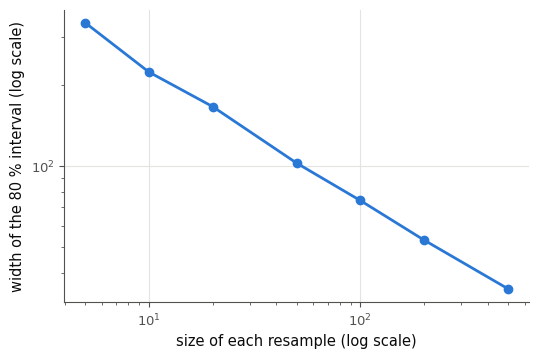

coverage: size 20 → 1.00 · size 500 → 0.84
width for 100, 1 000 and 10 000 resamples: [30.3, 34.9, 33.5]


In [41]:
def ci_width(sample_size, rng, n_boot=1000):
    """Width (high - low) of the 80 % bootstrap interval of the mean of sample_23 (n_boot resamples of sample_size)."""
    low, high = mylearn.stats.bootstrap_ci(sample_23, confidence=0.8, n_boot=n_boot, sample_size=sample_size, rng=rng)
    return high - low


def widths_by_size():
    """The list of ci_width(size, np.random.default_rng(1)) for every size of SIZES_23."""
    return [ci_width(size, np.random.default_rng(1)) for size in SIZES_23]


def coverage(sample_size, n_repeats, rng):
    """Share of n_repeats new surveys (500 values drawn WITHOUT replacement from population) whose 80 % bootstrap
    interval (500 resamples of size sample_size) contains population.mean(). One generator rng for everything."""
    true_mean = population.mean()
    hits = 0
    for _ in range(n_repeats):
        new_sample = mylearn.stats.sample(population, 500, replace=False, rng=rng)
        low, high = mylearn.stats.bootstrap_ci(new_sample, confidence=0.8, n_boot=500, sample_size=sample_size, rng=rng)
        hits += low <= true_mean <= high
    return hits / n_repeats


widths_23 = widths_by_size()
ratio_23 = widths_23[SIZES_23.index(20)] / widths_23[SIZES_23.index(500)]
print(dict(zip(SIZES_23, np.round(widths_23, 1))), "· ratio 20 / 500:", round(ratio_23, 2))
print("width × √size:", np.round(np.array(widths_23) * np.sqrt(SIZES_23)))
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.loglog(SIZES_23, widths_23, "o-")
ax.set(xlabel="size of each resample (log scale)", ylabel="width of the 80 % interval (log scale)")
plt.show()
cover_20 = coverage(20, N_REPEATS_23, np.random.default_rng(7))
cover_500 = coverage(500, N_REPEATS_23, np.random.default_rng(7))
print(f"coverage: size 20 → {cover_20:.2f} · size 500 → {cover_500:.2f}")
print("width for 100, 1 000 and 10 000 resamples:", [round(ci_width(500, np.random.default_rng(1), n_boot=b), 1) for b in (100, 1000, 10_000)])

**Réponses (2.23)** :

1. Avec des rééchantillons de 20, l'intervalle à 80 % est environ **4,7 fois** plus large qu'avec des rééchantillons de 500, à peu près $\sqrt{500 / 20} = 5$. Sur le graphique en échelle logarithmique, les points sont presque alignés sur une droite de pente $-\frac{1}{2}$ : quand la taille est multipliée par 4, la largeur est divisée par 2. La largeur varie comme $\frac{1}{\sqrt{\text{taille}}}$ (le produit largeur × $\sqrt{\text{taille}}$ reste vers 700-800). Un rééchantillon de 20 imite un échantillon de 20 : il mesure l'incertitude qu'on aurait avec 20 valeurs, pas avec 500.
2. L'intervalle du livre contient la vraie moyenne **à chaque fois** (100 %) : il promet 80 % et donne beaucoup plus, parce qu'il est bien trop large. Avec des rééchantillons de 500, la couverture est proche de 80 % (84 % ici, sur 100 enquêtes, 80 % en mode complet sur 400 ; l'aléa est de ± 4 points sur 100 enquêtes) : la promesse est tenue.
3. Non : 100, 1 000 et 10 000 rééchantillons donnent des largeurs voisines. Le **nombre** de rééchantillons rend les bornes plus **stables** d'une exécution à l'autre (moins de bruit dans les percentiles) ; c'est la **taille** de l'échantillon, et donc des rééchantillons, qui fixe la largeur.

💡 Le livre présente la petite taille des rééchantillons comme un avantage (plus rapides à calculer). L'expérience montre le prix : un intervalle quelque 5 fois trop large, qui annonce une incertitude qu'on n'a pas. Aujourd'hui : des rééchantillons de taille $n$, de 1 000 à 10 000 fois (fiche, 🕰️).

### Ex 2.24 — Comparer avec `scipy.stats.bootstrap` 📦 ★★ ⏱️ 15 min
**Objectif :** utiliser l'outil professionnel du bootstrap en lisant sa documentation, et comparer ses intervalles aux tiens.  
**Prérequis :** Ex 2.22 · fiche §2.6 (🕰️) · documentation de `scipy.stats.bootstrap` · **Fil rouge :** Penguins · **Parcours :** R, C

SciPy fait le bootstrap en une ligne. Lis d'abord sa documentation (`help(scipy_stats.bootstrap)`, ou [en ligne](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html)) : le premier argument, `data`, est une **séquence d'échantillons**, même quand il n'y en a qu'un. On écrit donc `(chinstrap_mass,)`, un tuple d'un seul élément : sans la virgule, SciPy croit recevoir 68 échantillons d'une seule valeur et lève une erreur d'axe (essaie).

Avec `confidence_level=0.95`, `n_resamples=9999` (la valeur par défaut) et, à chaque appel, `rng=np.random.default_rng(0)` :
a) `ci_percentile` : l'intervalle **percentile** (`method="percentile"`) de la moyenne de `chinstrap_mass`, `[bas, haut]`, arrondi au gramme ;
b) `ci_bca` : l'intervalle de la méthode par défaut, `"BCa"` (arrondi au gramme) ;
c) `standard_error` : l'erreur type calculée par SciPy (l'attribut `standard_error` du résultat, 1 décimale) ; compare-la à 2.22 e.

La vérification compare aussi ton intervalle percentile de 2.22 b à celui de SciPy. Dans tes notes : pourquoi ne sont-ils pas identiques, alors que la méthode est la même (compare aussi les 1 000 premières valeurs de `bootstrap_distribution`, l'attribut du résultat de SciPy, avec ta distribution de 2.22) ?

In [42]:
result_pct = scipy_stats.bootstrap((chinstrap_mass,), np.mean, confidence_level=0.95, n_resamples=9999,
                                  method="percentile", rng=np.random.default_rng(0))
result_bca = scipy_stats.bootstrap((chinstrap_mass,), np.mean, confidence_level=0.95, n_resamples=9999,
                                  rng=np.random.default_rng(0))
ci_percentile = [result_pct.confidence_interval.low, result_pct.confidence_interval.high]
ci_bca = [result_bca.confidence_interval.low, result_bca.confidence_interval.high]
standard_error = result_pct.standard_error
mine_24 = mylearn.stats.bootstrap_ci(chinstrap_mass, rng=np.random.default_rng(0))
print("percentile:", np.round(ci_percentile, 1), "· BCa:", np.round(ci_bca, 1), "· standard error:", round(standard_error, 2))
print("yours (1 000 resamples):", np.round(mine_24, 1))
try:
    scipy_stats.bootstrap(chinstrap_mass, np.mean, rng=np.random.default_rng(0))   # the classic mistake: no tuple
except Exception as error:  # noqa: BLE001
    print("without the tuple:", type(error).__name__, "-", error)

percentile: [3643.  3823.9] · BCa: [3641.6 3822.4] · standard error: 46.01
yours (1 000 resamples): [3647.4 3822.4]
without the tuple: AxisError - `axis` is out of bounds for array of dimension 0


In [43]:
legacy_24 = scipy_stats.bootstrap((chinstrap_mass,), np.mean, confidence_level=0.95, n_resamples=9999,
                                  method="percentile", random_state=0).confidence_interval
shared_rng_24 = np.random.default_rng(0)                       # one generator used for both calls: a classic slip
scipy_stats.bootstrap((chinstrap_mass,), np.mean, n_resamples=9999, method="percentile", rng=shared_rng_24)
shared_24 = scipy_stats.bootstrap((chinstrap_mass,), np.mean, n_resamples=9999, rng=shared_rng_24).confidence_interval
wb.record("2.24a", ci_percentile, decimals=0, mistakes={"c'est l'intervalle BCa, la méthode par défaut : précise method=\"percentile\"": ci_bca,
                                                        "un entier comme random_state crée l'ANCIEN générateur de NumPy : passe rng=np.random.default_rng(0)": list(legacy_24)})
wb.record("2.24b", ci_bca, decimals=0, mistakes={"c'est l'intervalle percentile : ici, on veut la méthode par défaut (BCa)": ci_percentile,
                                                 "crée un NOUVEAU générateur de graine 0 pour cet appel : celui de a) a déjà servi": list(shared_24)})
wb.record("2.24c", standard_error, decimals=1)

WB_ANSWER {"decimals": 0, "element_hashes": ["1cb95afa56fb3444dfe801d0f6a07b7b6cb1269f58de8e55c5c7d6db27a5fdfc", "b74adba473b002c9e4d1c22e373ee874ed5f915f3ff88e993106159a673fa720"], "hash": "7befa1115935acecac00421a534d3f5897e52e6482446f20c5e40ccee759c5a9", "id": "2.24a", "kind": "array", "mistakes": {"64b4fca92f2bbc36c040cda72e220a0a86e94173a1785fab43fa0dfd1c0b6afb": "c'est l'intervalle BCa, la méthode par défaut : précise method=\"percentile\"", "9c1dcfed0e1bf9c6776acdcf46faa558e35dc9226c9637e25864a1b5ec3dcf9c": "un entier comme random_state crée l'ANCIEN générateur de NumPy : passe rng=np.random.default_rng(0)"}, "shape": [2]}
📝 Ex 2.24a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["f8bac6b60cac888eaeed165505eba13d6b97a4fdb8d0447bd3bad97c0807e5c4", "4b0f7766e5c88132f5a26d4ba6bd82d9eb7bfe00cbdeab940a52279c4506ca56"], "hash": "23f47f0168e5407af283b38ed970f056c3a29f582ab78c83dbc9209b9a3574ab", "id": "2.24b", "kind": "array", "mistakes": {"2

💡 Les deux intervalles percentile utilisent la même méthode, et même les mêmes premiers rééchantillons : SciPy tire tous ses indices d'un coup (`rng.integers(0, n, (9999, n))`), ce qui redonne exactement la suite de tes tirages ; les 1 000 premières valeurs de `result_pct.bootstrap_distribution` sont les tiennes. La seule différence est le nombre de rééchantillons, 1 000 contre 9 999 : l'écart de quelques grammes est le **bruit de Monte-Carlo** de 1 000 rééchantillons, et `bootstrap_ci(..., n_boot=9999)` redonne l'intervalle de SciPy à l'identique. L'intervalle BCa corrige le biais et l'asymétrie de la distribution bootstrap ; ici, sur des moyennes presque symétriques, il ne diffère que d'un ou deux grammes. En pratique : `scipy.stats.bootstrap`, avec la méthode par défaut, et `rng` pour la reproductibilité.

## Partie D · Grande dimension, covariance et corrélation, ddof, Anscombe

Fiche §2.7 à §2.9. Tu mesures des distances entre images de MNIST, tu écris covariance et corrélation et tu les appliques aux manchots, d'abord tous ensemble puis espèce par espèce, tu traques les pièges de ddof, puis tu redessines le quartet d'Anscombe et tu fabriques le tien.

In [44]:
bill_length = measured["bill_length_mm"].to_numpy(copy=True)     # in mm (a copy: the DataFrame stays intact)
bill_depth = measured["bill_depth_mm"].to_numpy(copy=True)       # in mm

### Ex 2.25 — Distances entre chiffres dans l'espace à 784 dimensions 📦 ★★ ⏱️ 25 min
**Objectif :** calculer des distances entre images vues comme des points à 784 dimensions, et constater qu'en grande dimension, des points au hasard sont tous à peu près à la même distance.  
**Prérequis :** 0B (distance, 101.3.2) · Ex 2.11 · fiche §2.7 · livre §2.7 · **Fil rouge :** MNIST · **Parcours :** M, C

`X_digits` contient 2 000 images de MNIST aplaties en vecteurs de 784 pixels, entre 0 et 1, et `y_digits` leurs labels. La distance entre deux images est la distance euclidienne de 0B, avec 784 termes : `np.linalg.norm(a - b)`.

a) `dist_01` : la distance entre les images 0 et 1 (2 décimales).
b) `nearest_index` : l'indice (le numéro de ligne dans `X_digits`) de l'image la plus proche de l'image 0, parmi les 1 999 autres. Calcule toutes les distances d'un coup, `np.linalg.norm(X_digits - X_digits[0], axis=1)` (broadcasting, 0A), puis écarte l'image 0 elle-même (sa distance vaut 0 : remplace-la par `np.inf`). Est-ce le même chiffre ? (la vérification affiche les deux labels)
c) `nn_accuracy` : pour chacune des **500 premières** images, cherche la plus proche parmi les 1 999 autres (une boucle sur les 500 images) ; quelle proportion a le même label que sa plus proche voisine (3 décimales) ? C'est déjà un classifieur, celui des plus proches voisins (ch. 13).
d) `same_vs_other` : parmi les 500 premières images, le rapport (distance moyenne entre deux images de chiffres **différents**) / (distance moyenne entre deux images du **même** chiffre), sur toutes les paires d'images distinctes (2 décimales).
e) `contrast_random` : le **contraste** d'un nuage de points est $\frac{d_{\max} - d_{\min}}{d_{\min}}$, où $d_{\min}$ et $d_{\max}$ sont la plus petite et la plus grande distance entre le point 0 et les autres points. Calcule-le pour 1 000 points tirés uniformément dans $[0, 1]^{784}$, `np.random.default_rng(0).random((1000, 784))` (4 décimales).
f) `contrast_mnist` : le contraste des 1 000 premières images de `X_digits` (2 décimales).

La cellule suivante trace le contraste de points tirés au hasard selon la dimension. Dans tes notes : que devient le contraste quand la dimension grandit ? Pourquoi les images de MNIST se comportent-elles autrement que des points tirés au hasard (pense à 2.11, question 6) ?

In [45]:
X_digits, y_digits = wb.datasets.load_mnist("train", n=2000, flatten=True, normalize=True, seed=0)   # 2 000 images
print(X_digits.shape, X_digits.dtype)

(2000, 784) float32


In [46]:
def distances_to(points, i):
    """Distances from point i to all the points (point i itself: infinity)."""
    d = np.linalg.norm(points - points[i], axis=1)
    d[i] = np.inf
    return d


def contrast(points):
    """(d_max - d_min) / d_min for the distances between point 0 and the other points."""
    d = distances_to(points, 0)[1:]
    return (d.max() - d.min()) / d.min()


dist_01 = float(np.linalg.norm(X_digits[0] - X_digits[1]))
nearest_index = int(np.argmin(distances_to(X_digits, 0)))
nn_accuracy = float(np.mean([y_digits[np.argmin(distances_to(X_digits, i))] == y_digits[i] for i in range(500)]))
X500, y500 = X_digits[:500], y_digits[:500]
D500 = np.array([np.linalg.norm(X500 - X500[i], axis=1) for i in range(500)])
upper = np.triu_indices(500, k=1)                                  # every pair (i, j) with i < j, once
same_digit = (y500[:, None] == y500[None, :])[upper]
same_vs_other = float(D500[upper][~same_digit].mean() / D500[upper][same_digit].mean())
contrast_random = float(contrast(np.random.default_rng(0).random((1000, 784))))
contrast_mnist = float(contrast(X_digits[:1000]))
print(dist_01, nearest_index, y_digits[0], y_digits[nearest_index], nn_accuracy, same_vs_other, contrast_random, contrast_mnist)

11.746440887451172 548 5 5 0.904 1.1596928834915161 0.13546919754835368 1.8526184558868408


In [47]:
wb.record("2.25a", dist_01, decimals=2, mistakes={"c'est le CARRÉ de la distance : prends la racine": dist_01 ** 2})
wb.record("2.25b", nearest_index, mistakes={"l'image 0 est à distance 0 d'elle-même : écarte-la (np.inf) avant de chercher la plus proche": 0})
wb.record("2.25c", nn_accuracy, decimals=3, mistakes={"une image est à distance 0 d'elle-même : écarte-la (np.inf) avant de chercher sa plus proche voisine": 1.0})
with_diagonal = (y500[:, None] == y500[None, :])
wb.record("2.25d", same_vs_other, decimals=2, mistakes={"ne compte pas une image avec elle-même (distance 0) parmi les paires du même chiffre": D500[~with_diagonal].mean() / D500[with_diagonal].mean(),
                                                        "c'est le rapport inverse : chiffres DIFFÉRENTS divisé par MÊME chiffre": 1 / same_vs_other})
wb.record("2.25e", contrast_random, decimals=4)
wb.record("2.25f", contrast_mnist, decimals=2)

WB_ANSWER {"decimals": 2, "hash": "6504b6e78ebf50f6fcd71b549eee225e84ef4bcd5a587a4646920af705f05d8e", "hash_coarse": "64e585fd9d81d6e848e31e2c05f80ed155e9d0173775c040d30f61fbc0a9053d", "id": "2.25a", "kind": "float", "magnitude": 1, "mistakes": {"6089e8473d84d42d1ed2ad5fa793a20e908322c4952ca770c6fcddb538740eb9": "c'est le CARRÉ de la distance : prends la racine"}, "sign": 1}
📝 Ex 2.25a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"hash": "1d291b5645a63c8e0570582fd2c7925e64125428b5f6562e4fd981e37e8ea7b1", "id": "2.25b", "kind": "int", "magnitude": 2, "mistakes": {"ff43befd33a9f32eac40817f334ed0d04405fbfcaa04170df845aba60e8a05d2": "l'image 0 est à distance 0 d'elle-même : écarte-la (np.inf) avant de chercher la plus proche"}, "sign": 1}
📝 Ex 2.25b : réponse enregistrée (int).
WB_ANSWER {"decimals": 3, "hash": "9098c555607bf17a541a507ebc4a7252022fd79dda1008bdd513648621ccf40c", "hash_coarse": "4221f06c0ab675f471d87200ebba16f7b3ac4e289993c71408e71e6fa809975f", "id": "2.25c", "ki

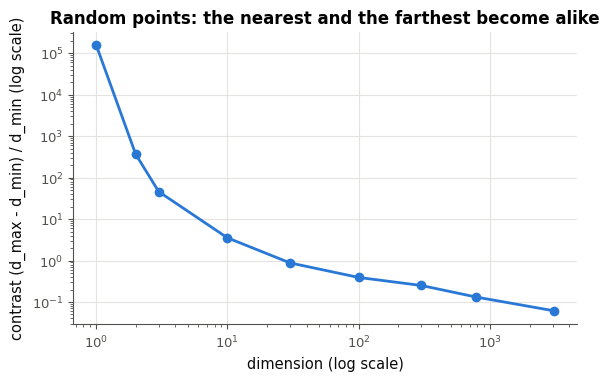

In [48]:
dims_25 = [1, 2, 3, 10, 30, 100, 300, 784, 3072]
contrasts_25 = []
for dim in dims_25:
    points = np.random.default_rng(1).random((1000, dim))          # 1 000 uniform points in [0, 1]^dim
    d = np.linalg.norm(points[1:] - points[0], axis=1)
    contrasts_25.append((d.max() - d.min()) / d.min())
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.loglog(dims_25, contrasts_25, "o-")
ax.set(xlabel="dimension (log scale)", ylabel="contrast (d_max - d_min) / d_min (log scale)",
       title="Random points: the nearest and the farthest become alike")
plt.show()

💡 En moyenne, deux images de chiffres différents ne sont qu'environ 16 % plus éloignées que deux images du même chiffre : en 784 dimensions, les distances se ressemblent beaucoup. Pour des points tirés au hasard, c'est pire : le point le plus lointain n'est qu'à 14 % de plus que le plus proche (contraste 0,14), contre un rapport de plus de 100 en dimension 2. C'est un visage de la **malédiction de la dimension** : « le plus proche » perd son sens. Les images de MNIST gardent un contraste d'environ 1,85 : elles ne remplissent pas l'espace au hasard, elles vivent près d'une structure de bien plus petite dimension (2.11, question 6), et la recherche du plus proche voisin marche (90 % de bons labels ici).

### Ex 2.26 — Covariance et corrélation 🔨 ★★ ⏱️ 25 min
**Objectif :** écrire la covariance et la corrélation, et les interpréter sur les mesures des manchots.  
**Prérequis :** Ex 2.7, Ex 2.15 · fiche §2.8.1, §2.8.2 · **Fil rouge :** Penguins · **mylearn :** `stats.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/stats.py`, mêmes règles qu'en 2.13 (NumPy permis, sauf les fonctions oracles). Enregistre, puis relance la cellule de vérification.

Écris `covariance(x, y, ddof=0)` et `correlation(x, y)`.
- `covariance` : la somme des produits des écarts à la moyenne, $(x_i - \bar{x})(y_i - \bar{y})$, divisée par $n - \mathrm{ddof}$ ; `x` et `y` doivent être deux tableaux à une dimension de même longueur (sinon, `ValueError`).
- `correlation` : la covariance divisée par les deux écarts-types, **avec le même ddof** (fiche §2.8.2) ; refuse une variable constante, dont l'écart-type est nul. Les arrondis peuvent donner `1.0000000000000002` : ramène le résultat dans $[-1, 1]$ (`np.clip`).

Aucune fonction ne modifie ses arguments : `np.asarray(x, dtype=float)` renvoie **le même** tableau quand `x` en est déjà un ; calcule `x - moyenne` dans un nouveau tableau, jamais avec `-=` (0A.56, « vue modifiée »).

Vérifications (la cellule de vérification les calcule avec tes fonctions) :
a) la covariance (ddof = 0) de la nageoire (mm) et de la masse (g) (1 décimale) ;
b) leur corrélation (3 décimales) ;
c) la covariance de la nageoire en **cm** et de la masse en **kg** (3 décimales) ; la vérification calcule aussi la corrélation en cm et en kg (2.8, question 6) ;
d) la corrélation de la **longueur** et de l'**épaisseur** du bec, sur tous les manchots (3 décimales). Un bec plus long serait-il plus fin ? Garde ta réponse : tu y reviens en 2.28.

La vérification trace les deux nuages de points de b et de d, puis lance les tests.

covariance: 9795.689699394685 mm·g · correlation: 0.8712017673060116
in cm and kg: covariance 0.9795689699394686 · correlation 0.8712017673060116
bill length and bill depth: -0.2350528703555327


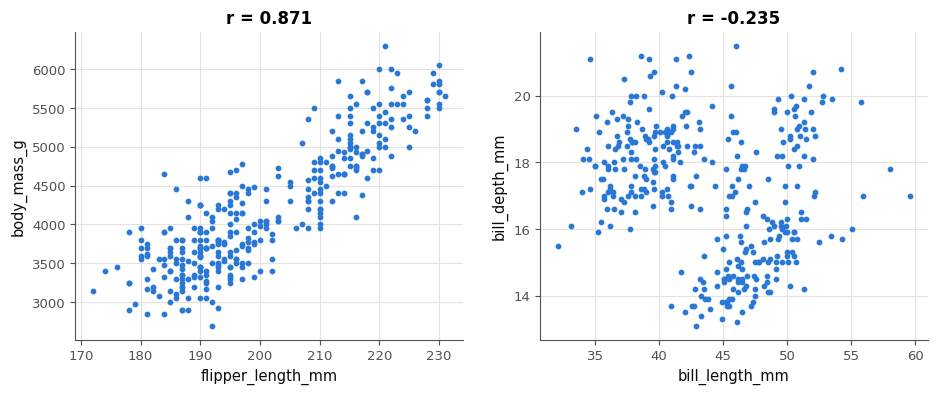

pytest: 16 passed, 101 deselected in 0.82s


In [49]:
st = mylearn.stats
print("covariance:", st.covariance(flipper, mass), "mm·g · correlation:", st.correlation(flipper, mass))
print("in cm and kg: covariance", st.covariance(flipper / 10, mass / 1000), "· correlation",
      st.correlation(flipper / 10, mass / 1000))
print("bill length and bill depth:", st.correlation(bill_length, bill_depth))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(flipper, mass, s=10)
axes[0].set(xlabel="flipper_length_mm", ylabel="body_mass_g", title=f"r = {st.correlation(flipper, mass):.3f}")
axes[1].scatter(bill_length, bill_depth, s=10)
axes[1].set(xlabel="bill_length_mm", ylabel="bill_depth_mm", title=f"r = {st.correlation(bill_length, bill_depth):.3f}")
plt.show()
run_stats_tests("(test_covariance_ or test_correlation_) and not matrix", impl="ref")

In [50]:
wb.record("2.26a", st.covariance(flipper, mass), decimals=1, mistakes={"ddof = 0 par défaut : divise par n, pas par n − 1": st.covariance(flipper, mass, ddof=1)})
wb.record("2.26b", st.correlation(flipper, mass), decimals=3, mistakes={"garde le même ddof pour la covariance et pour les écarts-types": st.covariance(flipper, mass, ddof=1) / (st.std(flipper) * st.std(mass))})
wb.record("2.26c", st.covariance(flipper / 10, mass / 1000), decimals=3,
          mistakes={"les deux unités changent : la nageoire est divisée par 10 ET la masse par 1 000": st.covariance(flipper / 10, mass)})
wb.record("2.26d", st.correlation(bill_length, bill_depth), decimals=3, mistakes={"le signe compte : regarde le sens du nuage de droite": -st.correlation(bill_length, bill_depth)})

WB_ANSWER {"decimals": 1, "hash": "d039d805b6ba89248a3350efc00dba567a81df4ddd2e025fff55dff9fac802e7", "hash_coarse": "4e9a4c1c15f1df45433fe250a784cd7b31fa3530846af523b0410a142866d803", "id": "2.26a", "kind": "float", "magnitude": 3, "mistakes": {"80f7109b6051a02b5c10df6c38964933e00b030df56540d444e11bad22e8bdb3": "ddof = 0 par défaut : divise par n, pas par n − 1"}, "sign": 1}
📝 Ex 2.26a : réponse enregistrée (float, 1 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "4af89449ad7d326dcea39389bfacf8d08995603da443af0e4d4d6f95c6d12779", "hash_coarse": "15c268713953d7a89ed0c301a10889ed8548218c8957843fb7de5877a4d0cb3b", "id": "2.26b", "kind": "float", "magnitude": -1, "mistakes": {"edab44bb11a12598551630291adef9ab529317db9e1a957426d1f38f8783734d": "garde le même ddof pour la covariance et pour les écarts-types"}, "sign": 1}
📝 Ex 2.26b : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "c60b6862523e49b6a5d5e5c71456b46656c06d2559736c5312359bc8055274f0", "hash_coarse

💡 La nageoire et la masse sont très liées ($r = 0{,}871$) : on peut prédire l'une à partir de l'autre avec une droite (la régression, ch. 9). Leur covariance, 9 796 mm·g, n'est pas interprétable seule : en cm et en kg, elle est divisée par $10 \times 1\,000$ et vaut 0,980, alors que la corrélation ne bouge pas. La corrélation longueur–épaisseur du bec est faiblement **négative** ($-0{,}235$) : sur le nuage, les points forment plusieurs paquets… la suite en 2.28.

### Ex 2.27 — Deviner la corrélation d'un nuage de points 📈 ★★ ⏱️ 20 min
**Objectif :** estimer une corrélation à l'œil, et repérer les nuages où elle trompe.  
**Prérequis :** Ex 2.26 · fiche §2.8.2 (⚠️ deux contresens) · livre §2.8.2 (figures 2.25 à 2.29) · **Fil rouge :** synthétique · **Parcours :** R, M

Les six nuages A à F ci-dessous ont chacun 60 points, et leurs corrélations sont affichées sous la figure, **dans l'ordre croissant**, pas dans l'ordre des nuages. **Sans rien calculer**, attribue à chaque nuage sa corrélation.

a) `r_guess` : la liste des six corrélations, dans l'ordre des nuages A, B, C, D, E, F (recopie les valeurs affichées) ;
b) `r_without_outlier` : un des nuages doit presque toute sa corrélation à un seul point. Retire ce point (le plus éloigné du centre du nuage) et calcule la corrélation des 59 autres (2 décimales), avec `np.corrcoef` ou ta fonction `correlation`. Les nuages sont dans `clouds_27`, un dictionnaire `{"A": (x, y), …}`.

La cellule **Réponse** affiche ensuite la vraie corrélation de chaque nuage. Puis, dans la cellule 📝 : quel nuage a une corrélation proche de 0 alors que $y$ dépend fortement de $x$ ? Pourquoi la corrélation ne le voit-elle pas ?

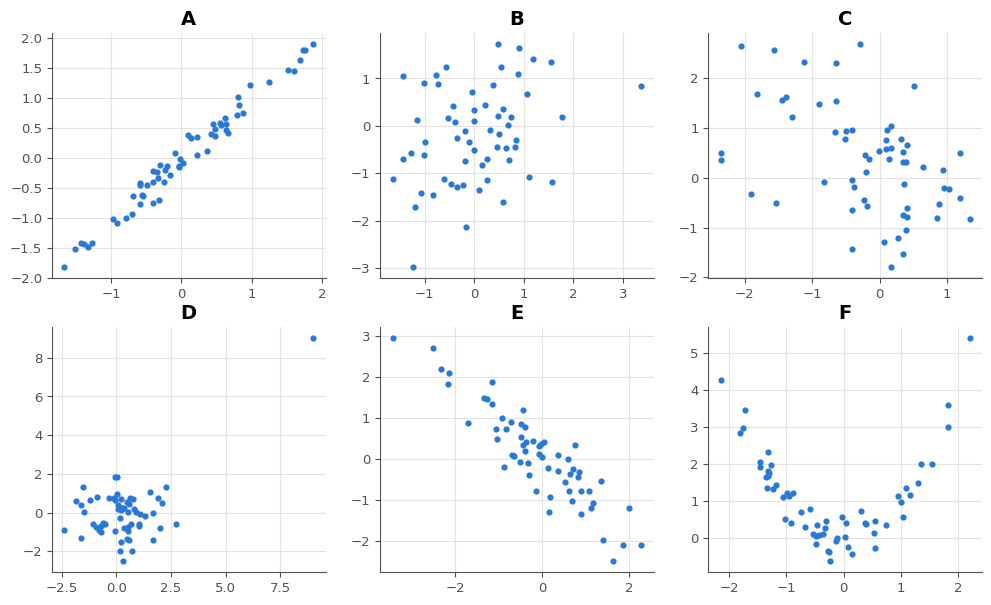

the six correlations, in increasing order (not in the order of the clouds): [-0.91, -0.45, -0.05, 0.31, 0.58, 0.99]


In [51]:
def make_clouds_27():
    """Six clouds of 60 points (x, y), named A to F in a shuffled order: guess by eye, do not read the recipes."""
    rng = np.random.default_rng(97)
    x = rng.normal(0, 1, (6, 60))
    e = rng.normal(0, 1, (6, 60))
    y = np.array([x[0] ** 2 + 0.3 * e[0], -x[1] + 0.45 * e[1], e[2], x[3] + 0.15 * e[3],
                  -0.6 * x[4] + e[4], 0.35 * x[5] + e[5]])
    x[2, 0], y[2, 0] = 9.0, 9.0
    order = rng.permutation(6)
    return {letter: (x[k], y[k]) for letter, k in zip("ABCDEF", order)}


clouds_27 = make_clouds_27()
R_VALUES_27 = sorted(round(float(np.corrcoef(x, y)[0, 1]), 2) for x, y in clouds_27.values())
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, (letter, (x, y)) in zip(axes.ravel(), clouds_27.items()):
    ax.scatter(x, y, s=12)
    ax.set_title(letter, fontsize=14)
plt.show()
print("the six correlations, in increasing order (not in the order of the clouds):", R_VALUES_27)

In [52]:
r_by_cloud = {letter: round(float(np.corrcoef(x, y)[0, 1]), 2) for letter, (x, y) in clouds_27.items()}
r_guess = list(r_by_cloud.values())
outlier_letter = next(letter for letter, (x, y) in clouds_27.items() if np.max(np.hypot(x, y)) > 8)
x_27, y_27 = clouds_27[outlier_letter]
far = np.argmax(np.hypot(x_27 - x_27.mean(), y_27 - y_27.mean()))       # the point farthest from the centre
r_without_outlier = float(np.corrcoef(np.delete(x_27, far), np.delete(y_27, far))[0, 1])
print(r_by_cloud, "· cloud with the isolated point:", outlier_letter, "· without it:", round(r_without_outlier, 3))

{'A': 0.99, 'B': 0.31, 'C': -0.45, 'D': 0.58, 'E': -0.91, 'F': -0.05} · cloud with the isolated point: D · without it: 0.009


In [53]:
wb.record("2.27a", r_guess, decimals=2)
wb.record("2.27b", r_without_outlier, decimals=2, mistakes={"c'est la corrélation AVEC le point isolé : retire-le d'abord": r_by_cloud[outlier_letter]})

WB_ANSWER {"decimals": 2, "element_coarse": [["c45259ae5255598380a068ca998a5795f3cd0f3f4a6c69758c308e9af5acad26"], ["88c6db0acb7e8ee0562f88b054eec3c05afcf8de5a7aa8e9ca8e59f96d146c18"], ["b5a085da0430564e11bc1e67040675265eaf1ece90364516d07d14edbbfadf74"], ["4e853cb47f581f56d1c084adb39c05392657020471258a648b10221555d4acbd"], ["d313c619817ebfe9a9e54be1dcfc5fff7023e2329ce14111c55c8e55e1d89626"], ["5651b7ae59c48809708c65a9fb4427955d639baebfe16f11f17dfe811e981f6a"]], "element_hashes": ["35751d4ed34a8b6001b03bb8548025d925083d14555d849b706769e7fea6b898", "7c045fb2c5833206cb63901948af748661451c107c42fc3c2080621095da8114", "3f66f5e0198e35bf32e7d97da1916d6dc0ae8be578c4aa5b0b981c56070fbe59", "98d8da5198ef74360463c2970da4fd58feaf8f15977290f26a6306369905a29b", "439ba8a5d802b3480742ad1b9949027a49ed2f8c6640bf1288c073f2008d050f", "21046d71a44ed2de25e8bc2ebe528ab633fffedcfa5da2293fd160130876462d"], "hash": "ce5acd2de0d66b54e8d4a1a26a51cff0c30f8a9a9e5bcdf10e5d92b25cd7cf17", "id": "2.27a", "kind": "array"

**Réponse** : exécute la cellule pour voir la vraie corrélation de chaque nuage.

In [54]:
if any(answer is ... or answer is None for answer in [r_guess]):
    print("⏳ Ex 2.27 : donne d'abord ta réponse a), puis relance cette cellule.")
else:
    for letter, (x, y) in clouds_27.items():
        print(f"{letter}: r = {np.corrcoef(x, y)[0, 1]:+.2f}")

A: r = +0.99
B: r = +0.31
C: r = -0.45
D: r = +0.58
E: r = -0.91
F: r = -0.05


**Réponses (2.27)** : le nuage F, en forme de U (une parabole) : $y$ se déduit presque de $x$, mais il monte à droite et à gauche du centre. Les produits des écarts $(x_i - \bar{x})(y_i - \bar{y})$ sont positifs d'un côté et négatifs de l'autre, et se compensent : la corrélation mesure seulement la part **linéaire** du lien (fiche, ⚠️ « Deux contresens »). À l'inverse, le nuage D n'a aucun lien, mais un seul point très éloigné lui donne une corrélation de 0,58 : sans lui, elle tombe à 0,01. Deux raisons de toujours regarder le nuage avant de croire un $r$.

💡 Les nuages A (0,99) et E (−0,91) se reconnaissent vite : des points serrés autour d'une droite. B (0,31) et C (−0,45) sont plus difficiles : un nuage large mais penché. Les deux pièges sont F (une parabole, $r \approx 0$ malgré un lien très fort) et D (un point isolé qui fabrique une corrélation). Tu retrouveras ce point **influent** dans le jeu IV d'Anscombe (2.12, 2.30).

### Ex 2.28 — Matrices de covariance et de corrélation des manchots 🔨 ★★ ⏱️ 25 min
**Objectif :** calculer les matrices de covariance et de corrélation d'un tableau, et comparer la corrélation de l'ensemble à celle de chaque groupe.  
**Prérequis :** Ex 2.26 · 0B (produit matriciel) · fiche §2.8 (🧮 matrice de covariance) · **Fil rouge :** Penguins · **mylearn :** `stats.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/stats.py`, mêmes règles qu'en 2.13 (NumPy permis, sauf les fonctions oracles). Enregistre, puis relance la cellule de vérification.

Écris `covariance_matrix(X, ddof=0)` et `correlation_matrix(X)`.
- `covariance_matrix` : `X` a une ligne par manchot et une colonne par mesure. Centre chaque colonne (soustrais la moyenne de la colonne), puis la case $(j, k)$ est la somme des produits des colonnes centrées $j$ et $k$, divisée par $n - \mathrm{ddof}$. Deux boucles sur $j$ et $k$ suffisent ; en une ligne, c'est `Xc.T @ Xc / (n - ddof)` (0B : vérifie les formes, $(p, n) \times (n, p)$ donne $(p, p)$).
- `correlation_matrix` : divise chaque case $(j, k)$ de la matrice de covariance par $\sigma_j\,\sigma_k$ ; la diagonale vaut 1.

Vérifications, sur `X_measures` (342 manchots × 4 mesures) :
a) la matrice de corrélation (4 × 4), que la vérification calcule avec ta fonction et affiche avec le nom des mesures ;
b) `most_negative` : d'après cette matrice, la paire de mesures la plus **négativement** corrélée (une liste de deux noms de `MEASURES`).

Ensuite, une question sur les espèces.

In [55]:
st = mylearn.stats
C_28 = st.covariance_matrix(X_measures)
R_28 = st.correlation_matrix(X_measures)
print(pd.DataFrame(C_28, index=MEASURES, columns=MEASURES).round(2))
print(pd.DataFrame(R_28, index=MEASURES, columns=MEASURES).round(3))
j, k = np.unravel_index(np.argmin(R_28), R_28.shape)
most_negative = [MEASURES[j], MEASURES[k]]
print("most negative pair:", most_negative)
run_stats_tests("test_covariance_matrix_ or test_correlation_matrix_", impl="ref")

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm              29.72          -2.53              50.23   
bill_depth_mm               -2.53           3.89             -16.17   
flipper_length_mm           50.23         -16.17             197.15   
body_mass_g               2597.97        -745.18            9795.69   

                   body_mass_g  
bill_length_mm         2597.97  
bill_depth_mm          -745.18  
flipper_length_mm      9795.69  
body_mass_g          641250.58  
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm              1.000         -0.235              0.656   
bill_depth_mm              -0.235          1.000             -0.584   
flipper_length_mm           0.656         -0.584              1.000   
body_mass_g                 0.595         -0.472              0.871   

                   body_mass_g  
bill_length_mm           0.595  
bill_depth_mm           -0.472  
flipper_length_mm       

pytest: 11 passed, 106 deselected in 0.85s


In [56]:
wb.record("2.28a", R_28, decimals=5)   # 4 decimals: two coefficients near a rounding limit
wb.record("2.28b", set(most_negative), mistakes={"c'est la paire la plus liée en valeur absolue ; on demande la plus NÉGATIVE (le coefficient le plus bas)": {"flipper_length_mm", "body_mass_g"}})

WB_ANSWER {"decimals": 5, "element_coarse": [["b5c08cfc7b0f76468d93f160eeeb6408b347909dbdd0d9442dea73e1d376017f"], ["22e33af1aa69c62c50f5afd0e4b80a24a2707aa6f4f752e7305bcbf1ae64d222"], ["4596044eeed3b2cbb66835a8794e64e947d7a4724db0ee6c10725f79866dd150"], ["43a408c1c5eae9ff2dd39c807ecf125699cb511c2f6cf5269f7ee4766980f3f9"], ["d5a71243e6f95f33982d8958716edd2ed72ef3313fbcd46c8ddc9f5acdf41f1b"], ["e56c7b509212d08aff631a073d3e0c2cd198c2476ea1f7ae195c15f3ae7ce4b9"], ["874e2a0e441206d2f7eb5ef8a2e08d6086b7d605ee371599d140a80eed6c1aff"], ["26f380838fa059e4127ea7a79b63f29b36eefa16bb4f13b3ed2385f4d726304a"], ["9d403339460474ba472be5b473638c98791a4df8ac84162f0f6117e79bbac573"], ["3e469f4ad665e71277502414fda5e5207b547efb31b6c9415fd751bb8556f97e"], ["bd4b620e29f2acc87519074c3deb0dee08b230f1bded205df0b2257d50ccfda7"], ["00ac04c9ac682fdc23eae2b11b8544dd2ced2fffde861611b703f90fd48c928c"], ["7a6b04765804c217b53bd54eb3a85128d2d9308d1ecfe2cec78a3431fb922d5a"], ["f9338bce85ee3b1155762e791858f98cfdc70d3adea

**Et dans chaque espèce ?** En 2.26 d, la corrélation entre la longueur et l'épaisseur du bec est **négative** sur l'ensemble des manchots : un bec plus long serait plus fin.

c) `prediction_gentoo` : **avant de calculer**, prédis le signe de cette corrélation chez les seuls Gentoo : `+1` si elle est positive, `-1` si elle est négative.

In [57]:
prediction_gentoo = +1

In [58]:
wb.record("2.28c", prediction_gentoo, mistakes={"chez des manchots d'une même espèce, un gros oiseau a-t-il un bec plus fin, ou un bec plus grand dans tous les sens ? Le signe global vient peut-être d'ailleurs": -1})

WB_ANSWER {"hash": "8881c7303c09828ef82b35c67086ec66a74eff4d4fc6c781aba93cd051a242a5", "id": "2.28c", "kind": "int", "magnitude": 0, "mistakes": {"1804416a7e192d1ca46fba4b4bb3acc05b8c26c38224c4f7c4694491e7c6b730": "chez des manchots d'une même espèce, un gros oiseau a-t-il un bec plus fin, ou un bec plus grand dans tous les sens ? Le signe global vient peut-être d'ailleurs"}, "sign": 1}
📝 Ex 2.28c : réponse enregistrée (int).


d) Écris `bill_r_by_species()` : la corrélation longueur–épaisseur du bec pour chaque espèce, dans l'ordre Adélie, Chinstrap, Gentoo (une liste, 2 décimales), avec ta `correlation` ou ta `correlation_matrix`. La vérification trace ensuite le nuage coloré par espèce, avec une droite par espèce et une pour l'ensemble.

In [59]:
def bill_r_by_species():
    """[r Adelie, r Chinstrap, r Gentoo]: correlation of bill length and bill depth within each species."""
    return [mylearn.stats.correlation(group["bill_length_mm"], group["bill_depth_mm"])
            for _, group in measured.groupby("species")]      # groupby sorts: Adelie, Chinstrap, Gentoo


print(np.round(bill_r_by_species(), 3), "· all the penguins:", round(mylearn.stats.correlation(bill_length, bill_depth), 3))

[0.391 0.654 0.643] · all the penguins: -0.235


In [60]:
wb.record("2.28d", bill_r_by_species(), decimals=2)

WB_ANSWER {"decimals": 2, "element_coarse": [["ad0c4c002148770c674995949a1336ac440cb5f1ef031136ae5e85d306318bed"], ["c4044fa8bcc5bd19e0f8962558dd9007b5d046772c986be183a619665a2d93bf"], ["2bc6fe86197a9994e383159faff6cd5b2389a4baede024985b505b9d34bd1cd4"]], "element_hashes": ["849741f367cb47ae3d004117df1484dadcc98f7568dbce3840c3c3aa6a049f74", "a0b1ba7f91eb6c2ce8fca30413d953972de46666e62dd385f14a9e5168a3df23", "9fce2c609266b422a6694ae824a119335ea1543af361e23dc421b7f10c725297"], "hash": "0911ab9bdf6ff88c3feb8bceb9bf5fd02fb816d5f521b1c684ae4d18f56ced1d", "id": "2.28d", "kind": "array", "shape": [3]}
📝 Ex 2.28d : réponse enregistrée (array, 2 décimale(s)).


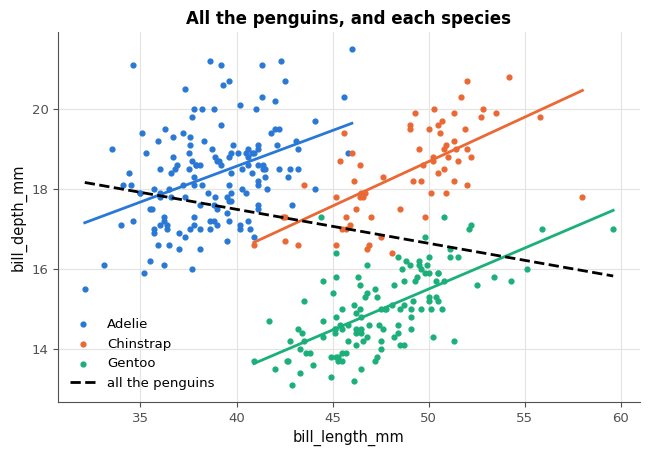

In [61]:
if any(answer is ... or answer is None for answer in [prediction_gentoo]):
    print("⏳ Ex 2.28 : écris d'abord ta prédiction c), puis relance cette cellule.")
else:
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    for species, group in measured.groupby("species"):
        ax.scatter(group["bill_length_mm"], group["bill_depth_mm"], s=12, label=species)
        slope, intercept = np.polyfit(group["bill_length_mm"], group["bill_depth_mm"], 1)
        ends = np.array([group["bill_length_mm"].min(), group["bill_length_mm"].max()])
        ax.plot(ends, intercept + slope * ends)
    slope, intercept = np.polyfit(bill_length, bill_depth, 1)
    ends = np.array([bill_length.min(), bill_length.max()])
    ax.plot(ends, intercept + slope * ends, "k--", label="all the penguins")
    ax.set(xlabel="bill_length_mm", ylabel="bill_depth_mm", title="All the penguins, and each species")
    ax.legend()
    plt.show()

**Réponses (2.28)** : dans chaque espèce, la corrélation est **positive** (0,39 chez les Adélie, 0,65 chez les Chinstrap, 0,64 chez les Gentoo) : un manchot plus grand a un bec plus long **et** plus épais. Mais les espèces diffèrent : les Adélie (151) ont des becs courts et épais, les Gentoo (123) des becs longs et fins. Ces deux gros paquets occupent deux coins opposés du nuage et tirent la corrélation globale vers le négatif ; les Chinstrap, aux becs longs et épais, l'atténuent seulement (sans eux, $r = -0{,}55$). C'est le **paradoxe de Simpson** (*Simpson's paradox*) : un lien peut changer de sens quand on réunit des groupes différents. L'espèce est ici une **variable de confusion** (fiche, ⚠️) ; le réflexe : colorer le nuage par groupe avant de conclure.

💡 La paire la plus négative est épaisseur du bec – nageoire ($-0{,}58$) : là encore, c'est l'effet des espèces (les Gentoo ont de longues nageoires et des becs fins). La matrice de covariance, elle, se lit mal : ses cases vont de −745 à 641 251, parce que les unités diffèrent (g², mm·g…) ; la matrice de corrélation les met toutes sur la même échelle. Tu repartiras de la matrice de covariance pour l'analyse en composantes principales (ch. 12).

### Ex 2.29 — Le piège de ddof : NumPy, pandas et toi 🐛 ★★ ⏱️ 20 min
**Objectif :** diagnostiquer trois bugs silencieux dus aux conventions de ddof et de `np.cov`, puis les corriger.  
**Prérequis :** Ex 2.28, Ex 2.7 · fiche §2.8 (🕰️ conventions ddof) · pandas (0A) · **Fil rouge :** Penguins · **Parcours :** C

Un collègue a écrit les trois fonctions ci-dessous. Elles tournent sans erreur… mais elles sont fausses. Mesure d'abord les dégâts :
a) `ratio_29` : `colleague_correlation(flipper, mass)` divisée par la vraie corrélation, `np.corrcoef(flipper, mass)[0, 1]` (4 décimales). Reconnais-tu ce nombre (indice : $n = 342$) ? Essaie aussi la fonction sur les cinq étudiants de 2.7 (`hours_2_7`, `grades_2_7`) : que vaut le résultat ?
b) `shape_29` : la forme (`.shape`) du résultat de `colleague_cov_matrix(measured[MEASURES])` ;
c) `std_after_29` : l'écart-type avec ddof = 0 (`np.std`, la convention du `StandardScaler` de scikit-learn) de la colonne `body_mass_g` du tableau standardisé par `colleague_standardize(measured[MEASURES])` (4 décimales).

Puis corrige : écris `correlation_fixed(x, y)`, `cov_matrix_fixed(df)` (la matrice 4 × 4 des covariances des colonnes, ddof = 0) et `standardize_fixed(df)` (chaque colonne de moyenne 0 et d'écart-type 1 avec ddof = 0), avec NumPy ou pandas, sans `mylearn`. Dans tes notes, pour chaque bug : quelle convention a été mélangée, et comment l'aurais-tu repéré ?

In [62]:
def colleague_correlation(x, y):
    return np.cov(x, y)[0, 1] / (np.std(x) * np.std(y))


def colleague_cov_matrix(df):
    return np.cov(df.to_numpy())


def colleague_standardize(df):
    return (df - df.mean()) / df.std()


hours_2_7 = np.array([1, 2, 3, 4, 5])     # the five students of 2.7: hours of revision
grades_2_7 = np.array([2, 3, 5, 4, 6])    # and grades

In [63]:
ratio_29 = colleague_correlation(flipper, mass) / np.corrcoef(flipper, mass)[0, 1]
shape_29 = colleague_cov_matrix(measured[MEASURES]).shape
std_after_29 = float(np.std(colleague_standardize(measured[MEASURES])["body_mass_g"].to_numpy()))
print(ratio_29, 342 / 341, "· 2.7:", colleague_correlation(hours_2_7, grades_2_7), "·", shape_29, "·", std_after_29)


def correlation_fixed(x, y):
    """Pearson correlation of x and y."""
    return float(np.cov(x, y, ddof=0)[0, 1] / (np.std(x) * np.std(y)))      # the same ddof everywhere


def cov_matrix_fixed(df):
    """Covariance matrix (ddof=0) of the COLUMNS of df: shape (number of columns, number of columns)."""
    return np.cov(df.to_numpy(), rowvar=False, ddof=0)                       # rows = samples, columns = variables


def standardize_fixed(df):
    """Every column minus its mean, divided by its standard deviation with ddof=0."""
    return (df - df.mean()) / df.std(ddof=0)                                 # pandas: ddof=1 by default


print(correlation_fixed(flipper, mass), correlation_fixed(hours_2_7, grades_2_7), cov_matrix_fixed(measured[MEASURES]).shape,
      standardize_fixed(measured[MEASURES]).to_numpy().std(axis=0))

1.0029325513196485 1.002932551319648 · 2.7: 1.1249999999999998 · (342, 342) · 0.9985369414257106
0.871201767306012 0.8999999999999998 (4, 4) [1. 1. 1. 1.]


In [64]:
wb.record("2.29a", ratio_29, decimals=4, mistakes={"divise la corrélation du collègue par la vraie, pas l'inverse": 1 / ratio_29})
wb.record("2.29b", shape_29, mistakes={"c'est la forme attendue ; mesure ce que le code du collègue renvoie VRAIMENT (exécute-le)": (4, 4)})
wb.record("2.29c", std_after_29, decimals=4, mistakes={"mesure avec ddof = 0 (np.std), pas avec la méthode .std() de pandas, qui divise par n − 1": 1.0})

WB_ANSWER {"decimals": 4, "hash": "30868ec22934ea94d3dbd3207d8d5f7eaa6a103f71626ff344bd9c8b5cd7bbe2", "hash_coarse": "b6a15b49eab198614f967c9bb154ef1d0bb8b4913624b3b84352009c87c9c234", "id": "2.29a", "kind": "float", "magnitude": 0, "mistakes": {"5f17706e42914089c2decb8f69851602b7bbfc03e1eeca6ec7e6db6af36af691": "divise la corrélation du collègue par la vraie, pas l'inverse"}, "sign": 1}
📝 Ex 2.29a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["3f3fb0468e687d46a2c1b740b4e19f3449aa092c2950138b82079723be2336de", "7ae550c7477cbeb0d540c657893b950c3630da863dc91ba39b13be8dc65635ab"], "hash": "b96275571360353a52160442467f794ebb3c2b0d8192af8a3193f69b718d85d6", "id": "2.29b", "integer": true, "kind": "array", "mistakes": {"5aa7f73c692a321f4a41fd17a363e18a42cec6de15cd1c032db04bac7c963ae9": "c'est la forme attendue ; mesure ce que le code du collègue renvoie VRAIMENT (exécute-le)"}, "shape": [2]}
📝 Ex 2.29b : réponse enregistrée (array, 0 décimale(s)).

💡 Bug 1 : `np.cov` divise par $n - 1$ par défaut, `np.std` par $n$ : la corrélation est multipliée par $\frac{n}{n - 1}$, soit 1,0029 pour 342 manchots (invisible) et 1,25 pour 5 points, où elle devient 1,125, impossible pour une corrélation (c'est l'erreur classique de 2.7 f). Bug 2 : `np.cov` prend chaque **ligne** pour une variable : sans `rowvar=False`, on obtient 342 × 342 covariances entre manchots. Bug 3 : `.std()` de pandas divise par $n - 1$ ; les colonnes standardisées ont un écart-type de 0,9985 au sens de NumPy et de scikit-learn, et ne coïncident pas avec un `StandardScaler`. Réflexe : **toujours écrire `ddof` explicitement**, et vérifier les formes (`.shape`) après chaque étape.

### Ex 2.30 — Le quartet d'Anscombe 🎨 ★★ ⏱️ 25 min
**Objectif :** redessiner le quartet d'Anscombe avec ses droites de régression, et voir que ses statistiques coïncident… pas toutes.  
**Prérequis :** Ex 2.26, Ex 2.12 · fiche §2.9 · livre §2.9 (figures 2.31 et 2.32) · **Parcours :** M, C

Les quatre jeux d'Anscombe sont dans `ANSCOMBE`, un dictionnaire `{"I": (x, y), …}`. Écris :
- `fit_line(x, y)` : la **droite de régression** de $y$ en $x$, sous la forme `(intercept, slope)`. Sa pente est $a = \frac{\mathrm{Cov}(x, y)}{\mathrm{Var}(x)}$ et son ordonnée à l'origine $b = \bar{y} - a\,\bar{x}$ (formules admises ici, démontrées au ch. 9), avec tes fonctions de `mylearn.stats` ou avec NumPy ;
- `draw_quartet()` : la figure du livre (figure 2.31) : quatre panneaux (2 × 2), chaque nuage avec sa droite, les **mêmes axes** pour les quatre (`sharex=True, sharey=True`), et un titre par panneau.

La vérification contrôle que les quatre jeux ont bien, à 0,01 près, la même moyenne et la même variance de $x$ et de $y$, la même corrélation et la même droite ; puis :
a) `medians_y` : la médiane de $y$ dans chacun des quatre jeux (liste, 2 décimales). Toutes les statistiques sont-elles égales ?
b) `max_residuals` : pour chaque jeu, le plus grand écart $|y_i - (b + a\,x_i)|$ entre un point et **sa** droite (liste, 2 décimales) ;
c) `slope_iii_clean` : la pente de la droite de régression du jeu III privé de son point isolé, celui du plus grand écart (3 décimales). Que vaut alors sa corrélation ?

In [65]:
x_123 = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], dtype=float)
ANSCOMBE = {   # F. J. Anscombe, "Graphs in Statistical Analysis", 1973 (public domain)
    "I": (x_123, np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])),
    "II": (x_123, np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])),
    "III": (x_123, np.array([7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73])),
    "IV": (np.array([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], dtype=float),
           np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])),
}

[7.58, 8.14, 7.11, 7.04] [1.921 1.901 3.241 1.839] 0.34538961038961047 0.9999965537848281


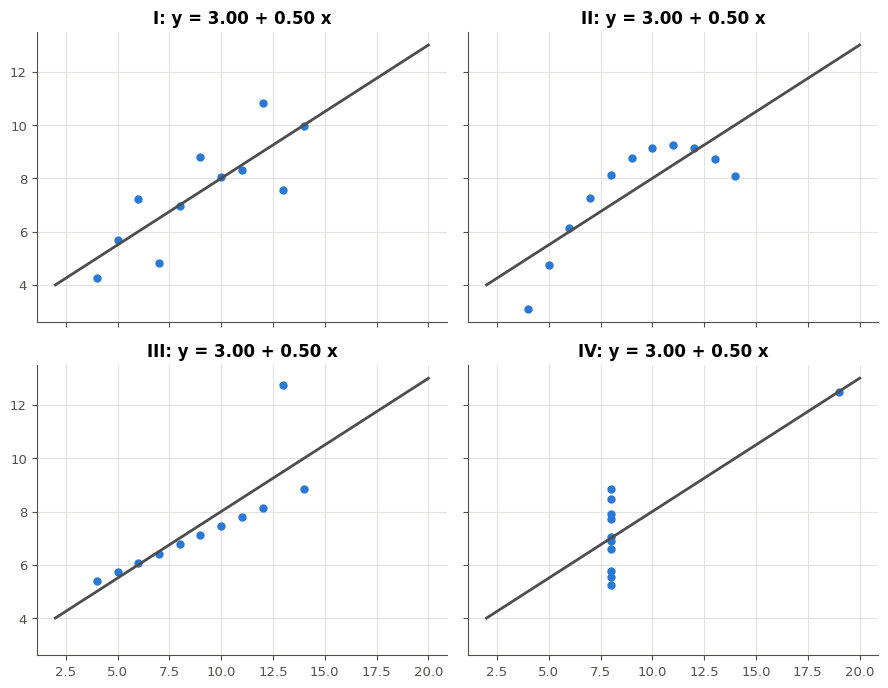

In [66]:
def fit_line(x, y):
    """(intercept, slope) of the least-squares line of y on x."""
    slope = mylearn.stats.covariance(x, y) / mylearn.stats.variance(x)
    return mylearn.stats.mean(y) - slope * mylearn.stats.mean(x), slope


def draw_quartet():
    """Figure 2 x 2: the four sets of ANSCOMBE, each with its line, the same axes everywhere."""
    fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True)
    ends = np.array([2, 20])
    for ax, (name, (x, y)) in zip(axes.ravel(), ANSCOMBE.items()):
        intercept, slope = fit_line(x, y)
        ax.scatter(x, y, s=25)
        ax.plot(ends, intercept + slope * ends, color="0.3")
        ax.set_title(f"{name}: y = {intercept:.2f} + {slope:.2f} x")
    fig.tight_layout()


def largest_residual(x, y):
    """Index and size of the largest |y_i - line(x_i)|."""
    intercept, slope = fit_line(x, y)
    residuals = np.abs(y - (intercept + slope * x))
    return int(np.argmax(residuals)), float(residuals.max())


medians_y = [float(np.median(y)) for _, y in ANSCOMBE.values()]
max_residuals = [largest_residual(x, y)[1] for x, y in ANSCOMBE.values()]
x_iii, y_iii = ANSCOMBE["III"]
worst = largest_residual(x_iii, y_iii)[0]
slope_iii_clean = fit_line(np.delete(x_iii, worst), np.delete(y_iii, worst))[1]
r_iii_clean = float(np.corrcoef(np.delete(x_iii, worst), np.delete(y_iii, worst))[0, 1])
print(medians_y, np.round(max_residuals, 3), slope_iii_clean, r_iii_clean)
draw_quartet()
plt.show()

In [67]:
wb.record("2.30a", medians_y, decimals=2, mistakes={"c'est la moyenne de y, la même dans les quatre jeux : on demande la médiane": [7.5, 7.5, 7.5, 7.5]})
signed_30 = [float(np.max(y - (fit_line(x, y)[0] + fit_line(x, y)[1] * x))) for x, y in ANSCOMBE.values()]
wb.record("2.30b", max_residuals, decimals=2, mistakes={"prends la valeur absolue des écarts : un point peut être loin EN DESSOUS de sa droite": signed_30})
wb.record("2.30c", slope_iii_clean, decimals=3, mistakes={"c'est la pente AVEC le point isolé : retire-le d'abord": fit_line(x_iii, y_iii)[1]})

WB_ANSWER {"decimals": 2, "element_coarse": [["7cf075179d12e6de7596a5f2ec29228c3fb7b2d59e9a60c8abb7090a987383a8"], ["77d2e04076920f9c2f7111668e50a949f3b69b08d1df4e61799426463d77f1d6"], ["10df384bae757c8444df41914631dbc31b90242b3657465af8cc2c2255b8d35c"], ["26a4162762536c6a399ea06c4126715876a793a5f4ac85f3e00f343d762ff9b3"]], "element_hashes": ["4b4787a0b84976f46b43a62f894f31a8e501cd933ffa35aa6019c94a73e5d098", "ac794340e56a4b41030e3f7e092ad5ba8f48c89673982a0801260363be2c6460", "2449a17d9f21567c96cc7ac62db79020e83472ad53a4eb40ae5577edf0ae37e7", "2af1322aeb4f8d6850fd07afb609ff3dd7c7124a1743b5188dddd1d0c8364137"], "hash": "655b08cf731df926dae7ebee5537ccff6b1cea283029a084305797a4ac0ba9fc", "id": "2.30a", "kind": "array", "mistakes": {"409e55b084e6e005bd8e492db868ab59c3a4299bd139b3d305124121c0fe89cb": "c'est la moyenne de y, la même dans les quatre jeux : on demande la médiane"}, "shape": [4]}
📝 Ex 2.30a : réponse enregistrée (array, 2 décimale(s)).
WB_ANSWER {"decimals": 2, "element_coarse"

💡 Moyennes, variances, corrélation et droite coïncident, mais pas les médianes de $y$ (de 7,04 à 8,14) : les statistiques « identiques » d'Anscombe sont celles qu'il a choisies. Dans le jeu III, un seul point est à 3,24 de la droite ; sans lui, les dix autres sont alignés aux arrondis près ($r = 0{,}999997$), sur une autre droite, de pente 0,345. Le jeu IV (2.12) est le cas extrême : un seul point fabrique toute la pente. Un résumé chiffré ne remplace jamais le graphique.

### Ex 2.31 — Docstring et test pytest pour `zscore` 🛠️ ★★ ⏱️ 30 min
**Objectif :** documenter une fonction au format NumPy et écrire des tests pytest qui attrapent les cas limites d'une standardisation.  
**Prérequis :** Ex 2.15 · 0A.61, 0A.62 · fiche §2.3.2 · **Parcours :** C

Deux gestes de développeur, sur la standardisation de 2.15.

**1. Une docstring.** Écris `flag_outliers(x, threshold=3.0)` : elle renvoie les **indices** (un array d'entiers, dans l'ordre croissant) des valeurs dont le z-score (ddof = 0) dépasse `threshold` en valeur absolue ; calcule les z-scores avec `mylearn.stats.zscore`, et utilise `np.flatnonzero`. Donne-lui une docstring complète au format NumPy (comme en 0A.61) : un résumé d'une ligne, puis les sections `Parameters`, `Returns`, `Raises` (que se passe-t-il si les données sont constantes ?) et `Examples`, avec au moins **deux** exemples `>>>` que doctest vérifie. Pour un exemple, prends des valeurs dont tu peux calculer le résultat à la main : pour `[1, 1, 1, 1, 1, 1, 1, 1, 1, 10]`, calcule d'abord le z-score de 10 (moyenne, écart-type), puis choisis `threshold=2.5`. Pourquoi `threshold=3.0` serait-il un mauvais exemple ?

**2. Des tests.** Écris au moins **trois** tests pytest pour une fonction `zscore(x, ddof=0, axis=None)` qui a le contrat de `mylearn.stats.zscore` :
- une **propriété** : sur des données quelconques, le résultat a une moyenne 0 et un écart-type 1 (`pytest.approx`) ;
- un **cas limite** : des données constantes lèvent une `ValueError` (`pytest.raises`) ;
- l'**axe** : avec `axis=0`, **chaque colonne** d'un tableau 2-D a une moyenne 0 et un écart-type 1.

Range-les dans la liste `my_zscore_tests`. Comme en 0A.62, la vérification lance vraiment pytest : tes tests doivent **passer** sur une version juste (`zscore_ok`) et **échouer** sur chacune des trois versions buggées fournies (lis-les : où est l'erreur ?). Tes tests ne peuvent utiliser que `zscore`, `np`, `math` et `pytest`.

In [68]:
def zscore_ok(x, ddof=0, axis=None):
    """A correct version, with the contract of mylearn.stats.zscore."""
    x = np.asarray(x, dtype=float)
    std = x.std(axis=axis, ddof=ddof, keepdims=True)
    if x.size == 0 or np.any(std == 0):
        raise ValueError("zscore() is undefined for constant data (standard deviation 0)")
    return (x - x.mean(axis=axis, keepdims=True)) / std


def zscore_bug_1(x, ddof=0, axis=None):
    x = np.asarray(x, dtype=float)
    var = x.var(axis=axis, ddof=ddof, keepdims=True)
    if x.size == 0 or np.any(var == 0):
        raise ValueError("constant data")
    return (x - x.mean(axis=axis, keepdims=True)) / var


def zscore_bug_2(x, ddof=0, axis=None):
    x = np.asarray(x, dtype=float)
    std = x.std(axis=axis, ddof=ddof, keepdims=True)
    return (x - x.mean(axis=axis, keepdims=True)) / np.where(std == 0, 1.0, std)


def zscore_bug_3(x, ddof=0, axis=None):
    x = np.asarray(x, dtype=float)
    std = x.std(ddof=ddof)
    if x.size == 0 or std == 0:
        raise ValueError("constant data")
    return (x - x.mean()) / std

In [69]:
def flag_outliers(x, threshold=3.0):
    """Find the values that are far from the mean, in standard deviations.

    Parameters
    ----------
    x : array-like of shape (n,)
        Numbers (no NaN), not all equal.
    threshold : float, default=3.0
        A value is flagged when the absolute value of its z-score (ddof=0) is
        strictly greater than ``threshold``.

    Returns
    -------
    np.ndarray of int
        The indices of the flagged values, in increasing order (possibly empty).

    Raises
    ------
    ValueError
        If the data are constant (standard deviation 0), empty or contain NaN
        (raised by ``mylearn.stats.zscore``).

    Examples
    --------
    >>> flag_outliers([1, 1, 1, 1, 1, 1, 1, 1, 1, 10], threshold=2.5)
    array([9])
    >>> flag_outliers([1, 2, 3, 4])
    array([], dtype=int64)
    >>> flag_outliers([4, 4, 4])
    Traceback (most recent call last):
        ...
    ValueError: standard deviation is 0 (constant data): the z-score is undefined
    """
    z = mylearn.stats.zscore(x)
    return np.flatnonzero(np.abs(z) > threshold)


def test_mean_0_and_std_1():
    z = zscore(np.array([3.0, -1.0, 4.0, 1.5, 9.0, 2.6]))
    assert z.mean() == pytest.approx(0, abs=1e-12)
    assert z.std() == pytest.approx(1)


def test_constant_data_raises():
    with pytest.raises(ValueError):
        zscore([5.0, 5.0, 5.0])


def test_axis_0_standardizes_every_column():
    X = np.array([[1.0, 100.0], [2.0, 300.0], [4.0, 200.0], [7.0, 900.0]])
    Z = zscore(X, axis=0)
    assert Z.mean(axis=0) == pytest.approx([0, 0], abs=1e-12)
    assert Z.std(axis=0) == pytest.approx([1, 1])


my_zscore_tests = [test_mean_0_and_std_1, test_constant_data_raises, test_axis_0_standardizes_every_column]

runner_31 = doctest.DocTestRunner(verbose=False)
for test in doctest.DocTestFinder().find(flag_outliers, "flag_outliers",
                                         globs={"np": np, "flag_outliers": flag_outliers, "mylearn": mylearn}):
    runner_31.run(test)
print(runner_31.summarize(verbose=False))
good_31 = wb.run_pytest(my_zscore_tests, subject=zscore_ok, name="zscore")
for bug in [zscore_bug_1, zscore_bug_2, zscore_bug_3]:
    result = wb.run_pytest(my_zscore_tests, subject=bug, name="zscore", quiet=True)
    print(bug.__name__, "caught:", result.failed + result.errors > 0, f"({result.failed} failed)")

TestResults(failed=0, attempted=3)


pytest : 3 passed in 0.07s


zscore_bug_1 caught: True (2 failed)


zscore_bug_2 caught: True (1 failed)


zscore_bug_3 caught: True (1 failed)


💡 Pour `[1, …, 1, 10]` (neuf fois 1), la moyenne vaut 1,9 et l'écart-type 2,7 : le z-score de 10 vaut exactement 3. Avec `threshold=3.0`, le test « strictement plus grand » tomberait pile sur la limite, et le résultat dépendrait d'un arrondi de la dernière décimale : un exemple de documentation doit être net. Chaque test vise un bug : la propriété attrape la division par la variance (bug 1), le cas limite attrape la version qui renvoie des zéros au lieu de refuser (bug 2), et le test de l'axe attrape celle qui ignore `axis` (bug 3), à condition que les colonnes n'aient pas toutes la même moyenne et le même écart-type.

### Ex 2.32 — Mêmes statistiques, autre dessin : fabrique ton quartet 🏆 ★★★ ⏱️ 60 min
**Objectif :** fabriquer un nuage de forme imposée qui a exactement les statistiques d'Anscombe.  
**Prérequis :** Ex 2.30, Ex 2.15, Ex 2.8 · fiche §2.9 (🕰️ Datasaurus) · **Fil rouge :** synthétique · **Parcours :** M, C

**Défi.** Ajoute un cinquième jeu au quartet, en forme de **cœur**, avec les statistiques d'Anscombe à 0,01 près :
- moyenne de $x$ : 9 ; moyenne de $y$ : 7,50 ;
- variance de $x$ : 11 et variance de $y$ : 4,125, **avec ddof = 1** (les chiffres des tableaux habituels, 2.12) ;
- corrélation : 0,816 (et donc la même droite, $y \approx 3 + 0{,}5\,x$).

`heart_points(40)` fournit 40 points $(h_x, h_y)$ le long d'un cœur. Écris `make_heart_dataset(n=40)`, qui renvoie `(x, y)`, deux arrays de $n$ nombres obtenus à partir de $h_x$ et $h_y$ par des **opérations affines** seulement (multiplier par un nombre, ajouter un nombre, additionner $h_x$ et $h_y$ multipliés par des nombres), pour que le cœur reste reconnaissable, étiré ou penché.

Une méthode, à suivre pas à pas (sans algèbre linéaire) :
1. standardise $h_x$ (ddof = 0) : $z_x$ a une moyenne 0 et un écart-type 1 ;
2. retire de $h_y$ sa partie « en ligne droite » avec $z_x$ : $e = h_y - \bar{h}_y - c\,z_x$, avec $c = \mathrm{Cov}(h_y, z_x)$ ; alors $\mathrm{Cov}(e, z_x) = 0$ (vérifie-le, à partir de la définition de la covariance ou numériquement), puis standardise $e$ en $z_e$. Ici, le cœur est symétrique : tu trouveras $c \approx 0$, mais l'étape compte pour une forme penchée ;
3. pour la corrélation voulue $r$, pose $z_y = r\,z_x + \sqrt{1 - r^2}\,z_e$ : alors $z_y$ a un écart-type 1 et $\mathrm{Corr}(z_x, z_y) = r$ (le démontrer est un bon exercice, en développant la définition de la covariance) ;
4. remets les centres et les échelles : $x = 9 + s_x\,z_x$ et $y = 7{,}5 + s_y\,z_y$, où $s_x$ et $s_y$ sont les écarts-types voulus… avec le bon ddof : $z_x$ a été standardisé avec ddof = 0, les variances visées le sont avec ddof = 1.

La vérification contrôle les cinq statistiques et que ton nuage est bien une image affine du cœur, puis trace les quatre jeux d'Anscombe et le tien, chacun avec sa droite : cinq dessins, une seule droite. Pour aller plus loin : une autre forme (un cercle, une étoile, tes initiales), ou 400 points au lieu de 40.

In [70]:
x_123 = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], dtype=float)
ANSCOMBE = {   # F. J. Anscombe, "Graphs in Statistical Analysis", 1973 (public domain)
    "I": (x_123, np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])),
    "II": (x_123, np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])),
    "III": (x_123, np.array([7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73])),
    "IV": (np.array([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], dtype=float),
           np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])),
}


def heart_points(n=40):
    """n points (hx, hy) along a heart-shaped curve (the classic parametric heart), in the order of the curve."""
    t = np.linspace(0, 2 * np.pi, n, endpoint=False)
    hx = 16 * np.sin(t) ** 3
    hy = 13 * np.cos(t) - 5 * np.cos(2 * t) - 2 * np.cos(3 * t) - np.cos(4 * t)
    return hx, hy


def plot_quartet_and(x_new, y_new, name):
    """The four sets of ANSCOMBE and (x_new, y_new), each with its least-squares line."""
    fig, axes = plt.subplots(1, 5, figsize=(17, 3.6), sharex=True, sharey=True)
    for ax, (label, (x, y)) in zip(axes, [*ANSCOMBE.items(), (name, (x_new, y_new))]):
        slope, intercept = np.polyfit(x, y, 1)
        ax.scatter(x, y, s=14)
        ax.plot([0, 22], [intercept, intercept + 22 * slope], color="0.3")
        ax.set_title(f"{label}: y = {intercept:.2f} + {slope:.2f} x")
    plt.show()

9.0 7.5 11.0 4.124999999999999 0.816


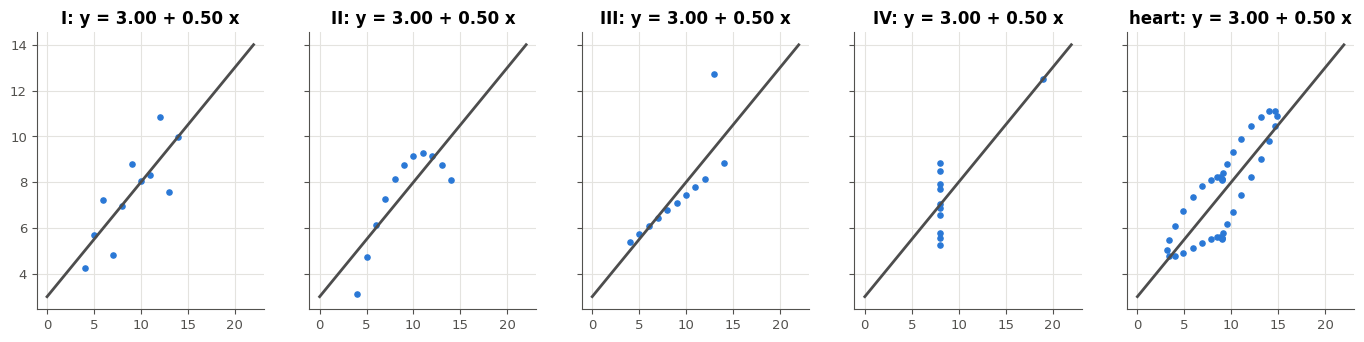

In [71]:
def make_heart_dataset(n=40):
    """(x, y): the heart of heart_points(n), transformed (affine operations only) to have Anscombe's statistics."""
    hx, hy = heart_points(n)
    zx = (hx - hx.mean()) / hx.std()                        # 1. mean 0, standard deviation 1 (ddof=0)
    e = hy - hy.mean() - np.mean((hy - hy.mean()) * zx) * zx  # 2. remove the straight-line part: Cov(e, zx) = 0
    ze = e / e.std()
    r = 0.816
    zy = r * zx + np.sqrt(1 - r ** 2) * ze                  # 3. standard deviation 1, correlation r with zx
    s_x = np.sqrt(11 * (n - 1) / n)                         # 4. ddof=1 variance 11 <=> ddof=0 std sqrt(11 (n-1)/n)
    s_y = np.sqrt(4.125 * (n - 1) / n)
    return 9 + s_x * zx, 7.5 + s_y * zy


x_32, y_32 = make_heart_dataset(40)
print(x_32.mean(), y_32.mean(), np.var(x_32, ddof=1), np.var(y_32, ddof=1), np.corrcoef(x_32, y_32)[0, 1])
plot_quartet_and(x_32, y_32, "heart")

💡 Pourquoi ça marche : $\mathrm{Var}(z_y) = r^2\,\mathrm{Var}(z_x) + (1 - r^2)\,\mathrm{Var}(z_e) + 2r\sqrt{1 - r^2}\,\mathrm{Cov}(z_x, z_e) = r^2 + 1 - r^2 + 0 = 1$, et $\mathrm{Cov}(z_x, z_y) = r\,\mathrm{Var}(z_x) + \sqrt{1 - r^2}\,\mathrm{Cov}(z_x, z_e) = r$. Le piège est l'étape 4 : $x = 9 + \sqrt{11}\,z_x$ donnerait une variance (ddof = 1) de $11 \times \frac{40}{39} \approx 11{,}28$. Matejka et Fitzmaurice (2017) vont plus loin : ils déplacent les points un par un en gardant les statistiques, ce qui permet d'atteindre n'importe quelle forme, pas seulement une image affine (fiche, 🕰️).

## ✅ Bilan

**Auto-évaluation** (note-toi de 0 à 3 dans `mon_travail/suivi/auto_evaluation.md`) :
1. Sais-tu choisir entre moyenne et médiane, et calculer variance et écart-type avec le bon diviseur ?
2. Sais-tu utiliser la règle 68-95-99,7 et dire quand elle ne s'applique pas ?
3. Sais-tu calculer une covariance et une corrélation, et dire ce qu'une corrélation ne prouve pas ?

**Pour aller plus loin** : *Seeing Theory* (Brown University) et le cours *Statistiques et probabilités* de Khan Academy, cités dans la fiche. La suite : le ch. 3 (probabilités conditionnelles, mesures de la qualité d'un classifieur), puis le bootstrap revient au ch. 14 (forêts aléatoires) et la matrice de covariance au ch. 12 (analyse en composantes principales).